# Ni-Cu Catalyst Adsorption Screening with FAIRChem / Open Catalyst Project Models

This notebook screens ethylidyne (coking-precursor surrogate) adsorption energies across Ni-Cu bimetallic catalyst
surfaces of varying composition, using Meta FAIR's **FAIRChem (formerly Open Catalyst Project, OCP)** universal
machine-learned interatomic potentials (UMA) as a fast surrogate for DFT, followed by targeted DFT validation on
top candidates.

## Attribution

This workflow builds directly on models and tools developed by the Open Catalyst Project / FAIR Chemistry team at
Meta AI. If you reuse this notebook, please cite:

```bibtex
@article{ocp_dataset,
  author  = {Chanussot*, Lowik and Das*, Abhishek and Goyal*, Siddharth and Lavril*, Thibaut and
             Shuaibi*, Muhammed and Riviere, Morgane and Tran, Kevin and Heras-Domingo, Javier and
             Ho, Caleb and Hu, Weihua and Palizhati, Aini and Sriram, Anuroop and Wood, Brandon and
             Yoon, Junwoong and Parikh, Devi and Zitnick, C. Lawrence and Ulissi, Zachary},
  title   = {Open Catalyst 2020 (OC20) Dataset and Community Challenges},
  journal = {ACS Catalysis},
  year    = {2021},
  doi     = {10.1021/acscatal.0c04525}
}
```

- FAIRChem / UMA models and code: [github.com/facebookresearch/fairchem](https://github.com/facebookresearch/fairchem)
- Documentation: [fair-chem.github.io](https://fair-chem.github.io/)
- The OC20 dataset is released under a CC BY 4.0 license; FAIRChem code license terms are in the repo above — check
  before redistributing any derived model weights.

## Data

This notebook expects your own local structure files (POSCAR/CONTCAR/extxyz) and energy summary `.txt` files as
input — none of that raw data is included here. Update the file paths below (currently placeholders like
`/content/...`) to point to your own data directory before running.


# Install packages

In [ ]:
!pip install fairchem-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.0/301.0 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.1/450.1 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/4

In [ ]:
from huggingface_hub import login

# Log in with your own Hugging Face token (do NOT hardcode tokens in notebooks).
# Running this will prompt for a token, or you can set the HF_TOKEN environment variable.
login()


In [ ]:
!pip install ase

In [ ]:
!pip install pymatgen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.1/809.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.4 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.3-py3-none-any.whl size=43549 sha256=8c410cf2ce30ed8f4b26985cf7094e9acf7d6f034f7c56ba3462195fff06c26d
  Stored in directory: /root/.cache/pip/wheels/1f/7d/e9/1ff2509f13767a55df1279744adfb757f4ab94b2cbe761f56a
Successfully built bibtexparser


# GPU (limited usage in colab) and CPU examples of FAIRCHEM

In [ ]:
from fairchem.core import pretrained_mlip
print(pretrained_mlip._MODEL_CKPTS.checkpoints.keys())


**GPU**

In [ ]:
from ase.build import fcc100, add_adsorbate, molecule
from ase.optimize import LBFGS
from fairchem.core import pretrained_mlip, FAIRChemCalculator

predictor = pretrained_mlip.get_predict_unit("uma-s-1", device="cuda")
calc = FAIRChemCalculator(predictor, task_name="oc20")

# Set up your system as an ASE atoms object
slab = fcc100("Cu", (3, 3, 3), vacuum=8, periodic=True)
adsorbate = molecule("CO")
add_adsorbate(slab, adsorbate, 2.0, "bridge")

slab.calc = calc

# Set up LBFGS dynamics object
opt = LBFGS(slab)
opt.run(0.05, 100)

**cpu**

In [ ]:
from ase.build import fcc100, add_adsorbate, molecule
from ase.optimize import LBFGS
from fairchem.core import pretrained_mlip, FAIRChemCalculator

# Force CPU usage
predictor = pretrained_mlip.get_predict_unit("uma-s-1", device="cpu")
calc = FAIRChemCalculator(predictor, task_name="oc20")

# Set up your system as an ASE atoms object
slab = fcc100("Cu", (3, 3, 3), vacuum=8, periodic=True)
adsorbate = molecule("CO")
add_adsorbate(slab, adsorbate, 2.0, "bridge")

slab.calc = calc

# Set up LBFGS dynamics object
opt = LBFGS(slab)
opt.run(0.05, 100)

# Ni/Cu surface with -CCH3

**Combined code to calculate adsorption energy and saving trajectories**

In [ ]:
from ase.build import add_adsorbate
from ase.io import read, write, extxyz
from ase.io.trajectory import Trajectory
from ase.optimize import LBFGS
from ase.constraints import FixAtoms
from ase.geometry import get_layers
from fairchem.core import pretrained_mlip, FAIRChemCalculator
import numpy as np
import torch
import os

# --- Setup device and model ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
predictor = pretrained_mlip.get_predict_unit("uma-s-1", device=device)
calc = FAIRChemCalculator(predictor, task_name="oc20")

# --- Load slab and adsorbate ---
slab = read('/content/POSCAR.vasp', format='vasp')
adsorbate = read('/content/POSCAR_CCH3.vasp', format='vasp')

# --- Constrain bottom layers of slab ---
layers, _ = get_layers(slab, (0, 0, 1), tolerance=0.3)
bottom_indices = np.where((layers == 0) | (layers == 1))[0]
slab.set_constraint(FixAtoms(indices=bottom_indices))
print(f"Constrained {len(bottom_indices)} atoms in bottom layers")

# --- Set tags for export (0 = fixed slab, 1 = surface slab, 2 = adsorbate) ---
tags = np.ones(len(slab))  # default: surface
tags[bottom_indices] = 0   # fixed atoms

# --- Calculate clean slab energy ---
clean_slab = slab.copy()
clean_slab.calc = calc
E_slab = clean_slab.get_potential_energy()
print(f"Clean slab energy: {E_slab:.4f} eV")

# --- Calculate isolated adsorbate energy ---
ads = adsorbate.copy()
ads.center(vacuum=5.0)
ads.set_pbc([False, False, False])
ads.calc = calc
E_ads = ads.get_potential_energy()
print(f"Isolated adsorbate energy: {E_ads:.4f} eV")

# --- Place adsorbate on slab ---
positions = slab.get_positions()
top_atom_index = np.argmax(positions[:, 2])
top_xy = positions[top_atom_index][:2]
add_adsorbate(slab, adsorbate, height=2.0, position=top_xy)
print(f"Placed adsorbate; total atoms: {len(slab)}")

# --- Update tags after adding adsorbate ---
tags = np.concatenate([tags, np.full(len(adsorbate), 2)])  # 2 = adsorbate
slab.set_tags(tags)

# --- Optimize combined system and save trajectory ---
os.makedirs('output', exist_ok=True)
slab.calc = calc
trajectory = Trajectory("output/adsorption_relax.traj", 'w', slab)
opt = LBFGS(slab, trajectory=trajectory)
opt.run(fmax=0.05, steps=100)
E_total = slab.get_potential_energy()
print(f"Total energy slab+adsorbate: {E_total:.4f} eV")

# --- Calculate adsorption energy ---
E_adsorption = E_total - E_slab - E_ads
print(f"Adsorption energy: {E_adsorption:.4f} eV")

# --- Save optimized structure ---
write('output/POSCAR_optimized.vasp', slab, format='vasp')
print("Optimized structure saved as output/POSCAR_optimized.vasp")

# --- Export trajectory to .extxyz format (OC20 style) ---
traj = read("output/adsorption_relax.traj", ":")
with open("output/adsorption_relax.extxyz", "w") as f:
    extxyz.write_xyz(f, traj, columns=["symbols", "positions", "tags", "move_mask"])

print("Trajectory exported to output/adsorption_relax.extxyz")


**Read trajectories**

In [ ]:
from ase.io import read

# Read all steps from the trajectory
traj = read("output/adsorption_relax.extxyz", index=":")

# Print energy for each step
for i, atoms in enumerate(traj):
    energy = atoms.get_potential_energy()
    print(f"Step {i}: Energy = {energy:.4f} eV")


**Viewing trajectory**

In [ ]:
import matplotlib.pyplot as plt
from ase.io import read
import ase.visualize.plot

traj = read("output/adsorption_relax.extxyz", index=":")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
labels = ['Initial', 'Middle', 'Final']

for i in range(3):
    ax[i].axis('off')
    ax[i].set_title(labels[i])

ase.visualize.plot.plot_atoms(traj[0], ax[0], radii=0.8, rotation=("-75x, 45y, 10z"))
ase.visualize.plot.plot_atoms(traj[len(traj)//2], ax[1], radii=0.8, rotation=("-75x, 45y, 10z"))
ase.visualize.plot.plot_atoms(traj[-1], ax[2], radii=0.8, rotation=("-75x, 45y, 10z"))

plt.tight_layout()
plt.savefig("output/relaxation_snapshots.png", dpi=300)
plt.show()


# Batch process

In [ ]:
import os
import zipfile
from ase.build import add_adsorbate
from ase.io import read, write, extxyz
from ase.io.trajectory import Trajectory
from ase.optimize import LBFGS
from ase.constraints import FixAtoms
from ase.geometry import get_layers
from fairchem.core import pretrained_mlip, FAIRChemCalculator
import numpy as np
import torch

# --- Setup device and model ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
predictor = pretrained_mlip.get_predict_unit("uma-s-1", device=device)
calc = FAIRChemCalculator(predictor, task_name="oc20")

# --- Load adsorbate once ---
adsorbate = read('/content/POSCAR_CCH3.vasp', format='vasp')

# --- Prepare output root ---
os.makedirs('batch_output', exist_ok=True)

# --- Loop over 50 slab files ---
for i in range(1, 51):
    slab_file = f'/content/POSCAR_{i}'
    slab_name = f'slab_{i}'
    output_dir = f'batch_output/{slab_name}'
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n--- Processing {slab_file} ---")

    # --- Read slab and apply constraints ---
    slab = read(slab_file, format='vasp')
    layers, _ = get_layers(slab, (0, 0, 1), tolerance=0.3)
    bottom_indices = np.where((layers == 0) | (layers == 1))[0]
    slab.set_constraint(FixAtoms(indices=bottom_indices))

    # --- Set tags ---
    tags = np.ones(len(slab))
    tags[bottom_indices] = 0

    # --- Clean slab energy ---
    clean_slab = slab.copy()
    clean_slab.calc = calc
    E_slab = clean_slab.get_potential_energy()

    # --- Isolated adsorbate energy ---
    ads = adsorbate.copy()
    ads.center(vacuum=5.0)
    ads.set_pbc([False, False, False])
    ads.calc = calc
    E_ads = ads.get_potential_energy()

    # --- Add adsorbate ---
    positions = slab.get_positions()
    top_atom_index = np.argmax(positions[:, 2])
    top_xy = positions[top_atom_index][:2]
    add_adsorbate(slab, adsorbate, height=2.0, position=top_xy)

    # --- Update tags ---
    tags = np.concatenate([tags, np.full(len(adsorbate), 2)])
    slab.set_tags(tags)

    # --- Optimize ---
    slab.calc = calc
    traj_path = os.path.join(output_dir, "adsorption_relax.traj")
    trajectory = Trajectory(traj_path, 'w', slab)
    opt = LBFGS(slab, trajectory=trajectory)
    opt.run(fmax=0.05, steps=100)
    E_total = slab.get_potential_energy()
    E_adsorption = E_total - E_slab - E_ads

    # --- Save optimized structure ---
    final_poscar_path = os.path.join(output_dir, "POSCAR_optimized.vasp")
    write(final_poscar_path, slab, format='vasp')

    # --- Save extxyz trajectory ---
    traj = read(traj_path, ":")
    extxyz_path = os.path.join(output_dir, "adsorption_relax.extxyz")
    with open(extxyz_path, "w") as f:
        extxyz.write_xyz(f, traj, columns=["symbols", "positions", "tags", "move_mask"])

    # --- Save energies ---
    with open(os.path.join(output_dir, "energies.txt"), "w") as f:
        f.write(f"Clean slab energy: {E_slab:.4f} eV\n")
        f.write(f"Isolated adsorbate energy: {E_ads:.4f} eV\n")
        f.write(f"Total slab+adsorbate energy: {E_total:.4f} eV\n")
        f.write(f"Adsorption energy: {E_adsorption:.4f} eV\n")

    print(f"Finished {slab_file} → Adsorption energy: {E_adsorption:.4f} eV")

# --- Zip all output folders ---
zipf = zipfile.ZipFile("batch_adsorption_results.zip", "w", zipfile.ZIP_DEFLATED)
for root, dirs, files in os.walk("batch_output"):
    for file in files:
        full_path = os.path.join(root, file)
        arcname = os.path.relpath(full_path, "batch_output")
        zipf.write(full_path, arcname)
zipf.close()

print("\n✅ All slabs processed and results zipped to 'batch_adsorption_results.zip'")


# Energy Summary

In [ ]:
import os
import pandas as pd
import re
from pathlib import Path

def extract_energy_values(file_path):
    """
    Extract energy values from energies.txt file
    Returns a dictionary with energy values
    """
    energy_data = {
        'clean_slab': None,
        'isolated_adsorbate': None,
        'total_slab_adsorbate': None,
        'adsorption': None
    }

    try:
        with open(file_path, 'r') as f:
            content = f.read()

        # Extract energy values using regex patterns
        clean_slab_match = re.search(r'Clean slab energy:\s*([-\d.]+)\s*eV', content)
        isolated_ads_match = re.search(r'Isolated adsorbate energy:\s*([-\d.]+)\s*eV', content)
        total_energy_match = re.search(r'Total slab\+adsorbate energy:\s*([-\d.]+)\s*eV', content)
        adsorption_match = re.search(r'Adsorption energy:\s*([-\d.]+)\s*eV', content)

        if clean_slab_match:
            energy_data['clean_slab'] = float(clean_slab_match.group(1))
        if isolated_ads_match:
            energy_data['isolated_adsorbate'] = float(isolated_ads_match.group(1))
        if total_energy_match:
            energy_data['total_slab_adsorbate'] = float(total_energy_match.group(1))
        if adsorption_match:
            energy_data['adsorption'] = float(adsorption_match.group(1))

    except Exception as e:
        print(f"Error reading file {file_path}: {e}")

    return energy_data

def compile_energy_data(base_directory='.', output_filename='compiled_energies.csv'):
    """
    Compile energy data from all slab folders
    """
    # Initialize list to store all data
    all_data = []

    # Process folders slab_1 to slab_50
    for i in range(1, 51):
        folder_name = f"slab_{i}"
        folder_path = os.path.join(base_directory, folder_name)
        energies_file = os.path.join(folder_path, "energies.txt")

        print(f"Processing {folder_name}...")

        # Check if folder and file exist
        if os.path.isdir(folder_path) and os.path.isfile(energies_file):
            # Extract energy values
            energy_data = extract_energy_values(energies_file)

            # Create row for this slab
            row_data = {
                'Folder_Number': i,
                'Clean_Slab_Energy_eV': energy_data['clean_slab'],
                'Isolated_Adsorbate_Energy_eV': energy_data['isolated_adsorbate'],
                'Total_Slab_Adsorbate_Energy_eV': energy_data['total_slab_adsorbate'],
                'Adsorption_Energy_eV': energy_data['adsorption']
            }

            all_data.append(row_data)
            print(f"✓ Extracted data from {folder_name}")

        else:
            # Add row with missing data
            row_data = {
                'Folder_Number': i,
                'Clean_Slab_Energy_eV': None,
                'Isolated_Adsorbate_Energy_eV': None,
                'Total_Slab_Adsorbate_Energy_eV': None,
                'Adsorption_Energy_eV': None
            }
            all_data.append(row_data)
            print(f"⚠️  {folder_name} or energies.txt not found")

    # Create DataFrame
    df = pd.DataFrame(all_data)

    # Save to CSV
    df.to_csv(output_filename, index=False)
    print(f"\n✅ Data compiled successfully!")
    print(f"📁 Results saved to: {output_filename}")

    # Display summary
    print(f"\n📊 Summary:")
    print(f"Total folders processed: {len(df)}")
    print(f"Successful extractions: {df['Clean_Slab_Energy_eV'].notna().sum()}")
    print(f"Missing data: {df['Clean_Slab_Energy_eV'].isna().sum()}")

    return df

# ===== MAIN EXECUTION =====

# If you're running this in Colab and need to upload files, uncomment the following:
# from google.colab import files
# uploaded = files.upload()

# Extract the zip file
import zipfile
zip_path = '/content/batch_adsorption_results.zip'
extract_path = '/content/extracted_data'

print("📦 Extracting zip file...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("✅ Zip file extracted successfully!")

# List contents to see the structure
print("\n📁 Contents of extracted folder:")
for item in os.listdir(extract_path):
    print(f"  - {item}")

print("\n🚀 Starting energy data extraction...")
print("=" * 50)

# Run the compilation - adjust base_directory to where slab folders are located
df_results = compile_energy_data(base_directory=extract_path, output_filename='compiled_energies.csv')

print("\n" + "=" * 50)
print("📋 First 10 rows of compiled data:")
print(df_results.head(10))

print("\n📊 Basic statistics:")
print(df_results.describe())

# Optional: Download the results file in Colab
print("\n💾 To download the results file, run the next cell:")
print("from google.colab import files")
print("files.download('compiled_energies.csv')")

# AdsorbML

In [ ]:
import random
import os
import numpy as np
from ase.io import read, write
from ase.constraints import FixAtoms
from ase import Atoms
from ase.optimize import LBFGS
from sklearn.cluster import KMeans
from pathlib import Path
from fairchem.core import pretrained_mlip, FAIRChemCalculator
import zipfile
import glob
import pandas as pd

# === Load POSCAR and adsorbate ===
atoms = read("/content/NiPOSCAR_SD.vasp")
adsorbate = read("/content/POSCAR_CCH3.vasp")

# === Initialize FAIRChem ML calculator ===
print("Loading ML model...")
predictor = pretrained_mlip.get_predict_unit("uma-s-1", device="cpu")
calc = FAIRChemCalculator(predictor, task_name="oc20")

# === Cluster atoms into 5 layers using KMeans on z-coordinates ===
z_positions = np.array([[atom.position[2]] for atom in atoms])
kmeans = KMeans(n_clusters=5, random_state=42).fit(z_positions)
labels = kmeans.labels_

# === Identify bottom 2 layers ===
layer_means = [(i, z_positions[labels == i].mean()) for i in range(5)]
sorted_layers = sorted(layer_means, key=lambda x: x[1])  # sort by height
bottom_two_labels = [sorted_layers[0][0], sorted_layers[1][0]]

# === Fix atoms in bottom 2 layers ===
fixed_indices = [i for i, label in enumerate(labels) if label in bottom_two_labels]

from ase.neighborlist import natural_cutoffs, NeighborList
from ase import Atom
import copy

# === AdsorbML-inspired constraint checking functions ===
def check_dissociation(initial_ads, final_ads):
    """Check if adsorbate dissociated during relaxation"""
    try:
        initial_nl = NeighborList(natural_cutoffs(initial_ads), self_interaction=False, bothways=True)
        initial_nl.update(initial_ads)

        final_nl = NeighborList(natural_cutoffs(final_ads), self_interaction=False, bothways=True)
        final_nl.update(final_ads)

        for i in range(len(initial_ads)):
            initial_neighbors = set(initial_nl.get_neighbors(i)[0])
            final_neighbors = set(final_nl.get_neighbors(i)[0])
            if initial_neighbors != final_neighbors:
                return True  # Dissociation detected
        return False
    except:
        return True  # Assume dissociation if check fails

def check_desorption(system, n_slab_atoms, cushion=1.5):
    """Check if adsorbate desorbed from surface"""
    try:
        adsorbate = system[n_slab_atoms:]
        surface = system[:n_slab_atoms]

        cutoffs = natural_cutoffs(system)
        cutoffs = [c * cushion for c in cutoffs]

        nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
        nl.update(system)

        for ads_idx in range(n_slab_atoms, len(system)):
            neighbors = nl.get_neighbors(ads_idx)[0]
            surface_neighbors = [n for n in neighbors if n < n_slab_atoms]
            if surface_neighbors:
                return False  # Still adsorbed
        return True  # Desorbed
    except:
        return True  # Assume desorbed if check fails

# ❌ Surface mismatch checking disabled
# def check_surface_mismatch(initial_surface, final_surface, cushion=2.0):
#     """Check for significant surface reconstruction with relaxed constraints"""
#     try:
#         ...
#     except Exception as e:
#         print(f"    Surface mismatch check failed: {e}")
#         return True

# === Enhanced adsorbate placement following AdsorbML methodology ===
def add_adsorbate_surface(slab, adsorbate, height=2.0, position_type="ontop"):
    slab_copy = slab.copy()
    adsorbate_copy = adsorbate.copy()

    surface_z = max([atom.position[2] for atom in slab_copy])
    surface_atoms = [i for i, atom in enumerate(slab_copy) if abs(atom.position[2] - surface_z) < 0.5]

    if position_type == "ontop":
        site_idx = random.choice(surface_atoms)
        site_pos = slab_copy[site_idx].position
    elif position_type == "bridge":
        if len(surface_atoms) >= 2:
            idx1, idx2 = random.sample(surface_atoms, 2)
            pos1, pos2 = slab_copy[idx1].position, slab_copy[idx2].position
            site_pos = [(pos1[0] + pos2[0])/2, (pos1[1] + pos2[1])/2, surface_z]
        else:
            site_idx = surface_atoms[0]
            site_pos = slab_copy[site_idx].position
    elif position_type == "hollow":
        if len(surface_atoms) >= 3:
            selected_atoms = random.sample(surface_atoms, min(3, len(surface_atoms)))
            avg_x = sum(slab_copy[i].position[0] for i in selected_atoms) / len(selected_atoms)
            avg_y = sum(slab_copy[i].position[1] for i in selected_atoms) / len(selected_atoms)
            site_pos = [avg_x, avg_y, surface_z]
        else:
            site_idx = surface_atoms[0]
            site_pos = slab_copy[site_idx].position

    wobble_range = 0.1
    site_pos[0] += random.uniform(-wobble_range, wobble_range)
    site_pos[1] += random.uniform(-wobble_range, wobble_range)

    rotation_angle = random.uniform(0, 2 * np.pi)
    center = adsorbate_copy.get_center_of_mass()
    adsorbate_copy.translate(-center)
    adsorbate_copy.rotate(rotation_angle, 'z')
    adsorbate_copy.translate(center)

    initial_pos = [site_pos[0], site_pos[1], surface_z + height]
    ads_com = adsorbate_copy.get_center_of_mass()
    translation = np.array(initial_pos) - ads_com
    adsorbate_copy.translate(translation)

    combined = slab_copy + adsorbate_copy
    min_distance = 1.0

    while True:
        distances = combined.get_all_distances()
        n_slab = len(slab_copy)
        min_dist = float('inf')
        for i in range(n_slab, len(combined)):
            for j in range(n_slab):
                min_dist = min(min_dist, distances[i][j])
        if min_dist >= min_distance:
            break
        for i in range(n_slab, len(combined)):
            combined[i].position[2] += 0.1
    return combined

# === Calculate reference energies ===
print("Calculating reference energies...")
gas_adsorbate = adsorbate.copy()
gas_adsorbate.calc = calc
gas_adsorbate_energy = gas_adsorbate.get_potential_energy()
print(f"Gas phase CCH3 energy: {gas_adsorbate_energy:.4f} eV")

clean_slab_energies = {}

# === Create output directories ===
output_dir = "generated_POSCARs"
optimized_dir = "optimized_structures"
clean_slabs_dir = "clean_slabs"  # NEW: Directory for clean slabs
trajectories_dir = "trajectory_files"  # NEW: Directory for trajectory files
os.makedirs(output_dir, exist_ok=True)
os.makedirs(optimized_dir, exist_ok=True)
os.makedirs(clean_slabs_dir, exist_ok=True)  # NEW: Create clean slabs directory
os.makedirs(trajectories_dir, exist_ok=True)  # NEW: Create trajectories directory

# === Configuration parameters ===
n_configs = 50
n_cu_atoms = 13
adsorption_sites = ["ontop", "bridge", "hollow"]

print(f"Generating and optimizing {n_configs} configurations...")

results_data = []

for i in range(1, n_configs + 1):
    print(f"\nProcessing configuration {i}/{n_configs}")
    new_atoms = atoms.copy()
    ni_indices = [atom.index for atom in new_atoms if atom.symbol == 'Ni']
    cu_indices = random.sample(ni_indices, min(n_cu_atoms, len(ni_indices)))
    for idx in cu_indices:
        new_atoms[idx].symbol = 'Cu'
    new_atoms.set_constraint(FixAtoms(indices=fixed_indices))

    sorted_atoms = sorted(new_atoms, key=lambda atom: atom.position[2])
    sorted_atoms_by_element = (
        [atom for atom in sorted_atoms if atom.symbol == 'Ni'] +
        [atom for atom in sorted_atoms if atom.symbol == 'Cu']
    )
    slab = Atoms(sorted_atoms_by_element,
                 cell=new_atoms.get_cell(),
                 pbc=new_atoms.get_pbc())
    if new_atoms.constraints:
        slab.set_constraint(new_atoms.constraints)

    # === NEW SECTION: Save clean slab POSCARs ===
    print(f"  Saving clean slab POSCAR...")
    clean_slab_file = os.path.join(clean_slabs_dir, f"POSCAR_clean_slab_{i}")
    write(clean_slab_file, slab, format='vasp', vasp5=True, direct=True)

    # Save composition info for clean slab
    ni_count_temp = len([atom for atom in slab if atom.symbol == 'Ni'])
    cu_count_temp = len([atom for atom in slab if atom.symbol == 'Cu'])
    with open(os.path.join(clean_slabs_dir, f"clean_slab_info_{i}.txt"), 'w') as f:
        f.write(f"Clean Slab Configuration: {i}\n")
        f.write(f"Ni atoms: {ni_count_temp}\n")
        f.write(f"Cu atoms: {cu_count_temp}\n")
        f.write(f"Composition: Ni{ni_count_temp}Cu{cu_count_temp}\n")
        f.write(f"Total slab atoms: {len(slab)}\n")
        f.write(f"Fixed atoms (bottom 2 layers): {len([idx for idx in fixed_indices if idx < len(slab)])}\n")
    # === END NEW SECTION ===

    adsorption_site = random.choice(adsorption_sites)
    system_with_ads = add_adsorbate_surface(slab, adsorbate, height=2.0, position_type=adsorption_site)
    n_slab_atoms = len(slab)
    constraint_indices = [idx for idx in fixed_indices if idx < n_slab_atoms]
    system_with_ads.set_constraint(FixAtoms(indices=constraint_indices))

    initial_file = os.path.join(output_dir, f"POSCAR_{i}")
    write(initial_file, system_with_ads, format='vasp', vasp5=True, direct=True)

    print(f"  Optimizing with {adsorption_site} site...")
    system_with_ads.calc = calc
    initial_adsorbate = system_with_ads[n_slab_atoms:].copy()
    initial_surface = system_with_ads[:n_slab_atoms].copy()

    try:
        # Save trajectory file in trajectories directory
        traj_file = os.path.join(trajectories_dir, f"optimization_{i}.traj")
        opt = LBFGS(system_with_ads, trajectory=traj_file)
        opt.run(fmax=0.05, steps=200)
        final_energy = system_with_ads.get_potential_energy()
        n_steps = opt.get_number_of_steps()

        final_adsorbate = system_with_ads[n_slab_atoms:].copy()
        final_surface = system_with_ads[:n_slab_atoms].copy()

        dissociated = check_dissociation(initial_adsorbate, final_adsorbate)
        desorbed = check_desorption(system_with_ads, n_slab_atoms)
        # surface_mismatch = check_surface_mismatch(initial_surface, final_surface)  # ❌ disabled

        constraint_violations = []
        if dissociated:
            constraint_violations.append("dissociation")
        if desorbed:
            constraint_violations.append("desorption")
        # if surface_mismatch:
        #     constraint_violations.append("surface_mismatch")

        if constraint_violations:
            print(f"  Configuration {i} FAILED constraint check: {', '.join(constraint_violations)}")

            # Create constraint check results for failed configurations
            failed_constraints_summary = f"FAILED: {', '.join(constraint_violations)}"
            dissociation_status = "FAILED" if "dissociation" in constraint_violations else "PASSED"
            desorption_status = "FAILED" if "desorption" in constraint_violations else "PASSED"
            surface_mismatch_status = "FAILED" if "surface_mismatch" in constraint_violations else "DISABLED"

            with open(os.path.join(optimized_dir, f"failed_{i}.txt"), 'w') as f:
                f.write(f"Configuration: {i}\n")
                f.write(f"Adsorption site: {adsorption_site}\n")
                f.write(f"Failed constraints: {', '.join(constraint_violations)}\n")
                f.write(f"Final energy: {final_energy:.6f} eV\n")
                f.write(f"Constraint Status:\n")
                f.write(f"  - Dissociation check: {dissociation_status}\n")
                f.write(f"  - Desorption check: {desorption_status}\n")
                f.write(f"  - Surface mismatch check: {surface_mismatch_status}\n")

            # Optional: Still add failed configurations to results with constraint info
            ni_count = len([atom for atom in slab if atom.symbol == 'Ni'])
            cu_count = len([atom for atom in slab if atom.symbol == 'Cu'])
            composition_key = f"Ni{ni_count}Cu{cu_count}"

            # Add failed configuration to results_data for tracking
            results_data.append({
                'config_id': i,
                'adsorption_site': adsorption_site,
                'total_energy': final_energy,
                'clean_slab_energy': 'N/A',
                'gas_phase_energy': gas_adsorbate_energy,
                'adsorption_energy': 'INVALID - Constraint Failed',
                'optimization_steps': n_steps if 'n_steps' in locals() else 'N/A',
                'ni_atoms': ni_count,
                'cu_atoms': cu_count,
                'composition': composition_key,
                'max_force': max([np.linalg.norm(f) for f in system_with_ads.get_forces()]) if system_with_ads else 'N/A',
                'structure_file': f"failed_{i}.txt",
                'constraints_passed': failed_constraints_summary,
                'dissociation_check': dissociation_status,
                'desorption_check': desorption_status,
                'surface_mismatch_check': surface_mismatch_status
            })
            continue

        print(f"  Optimization completed: {n_steps} steps, Energy: {final_energy:.3f} eV")
        print(f"  ✓ Constraints passed (no dissociation, no desorption)")

        ni_count = len([atom for atom in slab if atom.symbol == 'Ni'])
        cu_count = len([atom for atom in slab if atom.symbol == 'Cu'])
        composition_key = f"Ni{ni_count}Cu{cu_count}"

        if composition_key not in clean_slab_energies:
            clean_slab = slab.copy()
            clean_slab.calc = calc
            clean_slab_energy = clean_slab.get_potential_energy()
            clean_slab_energies[composition_key] = clean_slab_energy
            print(f"    Clean slab energy ({composition_key}): {clean_slab_energy:.4f} eV")
        else:
            clean_slab_energy = clean_slab_energies[composition_key]

        adsorption_energy = final_energy - clean_slab_energy - gas_adsorbate_energy
        print(f"    Adsorption energy: {adsorption_energy:.4f} eV")

        results_data.append({
            'config_id': i,
            'adsorption_site': adsorption_site,
            'total_energy': final_energy,
            'clean_slab_energy': clean_slab_energy,
            'gas_phase_energy': gas_adsorbate_energy,
            'adsorption_energy': adsorption_energy,
            'optimization_steps': n_steps,
            'ni_atoms': ni_count,
            'cu_atoms': cu_count,
            'composition': composition_key,
            'max_force': max([np.linalg.norm(f) for f in system_with_ads.get_forces()]),
            'structure_file': f"structure_{i}_optimized_{adsorption_site}.xyz",
            'constraints_passed': 'PASSED: No dissociation, No desorption',
            'dissociation_check': 'PASSED',
            'desorption_check': 'PASSED',
            'surface_mismatch_check': 'DISABLED'
        })

        optimized_file = os.path.join(optimized_dir, f"POSCAR_{i}_optimized_{adsorption_site}")
        write(optimized_file, system_with_ads, format='vasp', vasp5=True, direct=True)

        xyz_file = os.path.join(optimized_dir, f"structure_{i}_optimized_{adsorption_site}.xyz")
        write(xyz_file, system_with_ads, format='xyz')

        with open(os.path.join(optimized_dir, f"info_{i}.txt"), 'w') as f:
            f.write(f"Configuration: {i}\n")
            f.write(f"Adsorption site: {adsorption_site}\n")
            f.write(f"Optimization steps: {n_steps}\n")
            f.write(f"Total system energy: {final_energy:.6f} eV\n")
            f.write(f"Clean slab energy: {clean_slab_energy:.6f} eV\n")
            f.write(f"Gas phase energy: {gas_adsorbate_energy:.6f} eV\n")
            f.write(f"Adsorption energy: {adsorption_energy:.6f} eV\n")
            f.write(f"Cu atoms: {cu_count}\n")
            f.write(f"Ni atoms: {ni_count}\n")
            f.write(f"Ni:Cu ratio: {ni_count}:{cu_count}\n")
            f.write(f"Composition: {composition_key}\n")
            f.write(f"CCH3 (adsorbate) atoms: {len(adsorbate)}\n")
            f.write(f"Max force after optimization: {max([np.linalg.norm(f) for f in system_with_ads.get_forces()]):.4f} eV/Å\n")
            f.write(f"Constraints passed: dissociation, desorption\n")

    except Exception as e:
        print(f"  Optimization failed for configuration {i}: {str(e)}")
        continue

print(f"\nAll configurations processed!")
print(f"Initial structures saved in: {output_dir}")
print(f"Clean slabs saved in: {clean_slabs_dir}")  # NEW: Inform about clean slabs directory
print(f"Optimized structures saved in: {optimized_dir}")
print(f"Optimization trajectories saved in: {trajectories_dir}")

# === Save results to Excel file ===
print("\nSaving results to Excel file...")

# Create DataFrame from results_data
df_results = pd.DataFrame(results_data)

# Reorder columns for better readability
column_order = [
    'config_id',
    'adsorption_site',
    'composition',
    'ni_atoms',
    'cu_atoms',
    'constraints_passed',
    'dissociation_check',
    'desorption_check',
    'surface_mismatch_check',
    'total_energy',
    'clean_slab_energy',
    'gas_phase_energy',
    'adsorption_energy',
    'optimization_steps',
    'max_force',
    'structure_file'
]

df_results = df_results[column_order]

# Sort by adsorption energy (most favorable first)
df_results = df_results.sort_values('adsorption_energy', ascending=True)

# Save to Excel file
excel_filename = "adsorption_results.xlsx"
with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    # Main results sheet with all configurations
    df_results.to_excel(writer, sheet_name='All_Results', index=False)

    # Separate sheet for only passed configurations
    df_passed = df_results[df_results['constraints_passed'].str.contains('PASSED', na=False)]
    df_passed_sorted = df_passed.sort_values('adsorption_energy', ascending=True)
    df_passed_sorted.to_excel(writer, sheet_name='Passed_Only', index=False)

    # Separate sheet for failed configurations
    df_failed = df_results[df_results['constraints_passed'].str.contains('FAILED', na=False)]
    if not df_failed.empty:
        df_failed.to_excel(writer, sheet_name='Failed_Configs', index=False)

    # Format all worksheets
    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]

        # Auto-adjust column widths
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 25)  # Increased max width for constraint columns
            worksheet.column_dimensions[column_letter].width = adjusted_width

print(f"Results saved to: {excel_filename}")
print(f"Total successful configurations: {len(df_results)}")

# === Create a zip file with all results ===
print("\nCreating comprehensive zip file...")
zip_filename = "complete_adsorption_results.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:

    # Add all directories
    for directory in [output_dir, optimized_dir, clean_slabs_dir, trajectories_dir]:
        for root, dirs, files in os.walk(directory):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path)
                zipf.write(file_path, arcname)

    # Add Excel results file
    if os.path.exists(excel_filename):
        zipf.write(excel_filename, excel_filename)

    # Optionally add any other results files if they exist
    if os.path.exists("results_summary.csv"):
        zipf.write("results_summary.csv", "results_summary.csv")

    if os.path.exists("best_configuration.txt"):
        zipf.write("best_configuration.txt", "best_configuration.txt")

# Count trajectory files in trajectories directory
traj_files_count = len(glob.glob(os.path.join(trajectories_dir, "optimization_*.traj")))
print(f"All results (including {traj_files_count} trajectory files) compressed into: {zip_filename}")

# === Download zip file to local machine ===
from google.colab import files
files.download(zip_filename)

# """
# COMPREHENSIVE NI:CU SURFACE ADSORPTION ENERGY CALCULATION WITH ML OPTIMIZATION

# This code performs automated computational catalysis screening by:
# 1. Generating diverse Ni:Cu alloy surface slabs with random compositions
# 2. Adding CCH3 adsorbate molecules at different binding sites
# 3. Using machine learning potentials (FAIRChem) to optimize structures
# 4. Applying physical constraints to filter valid configurations
# 5. Ranking results by adsorption energy to identify optimal binding sites

# WORKFLOW BREAKDOWN:

# === PHASE 1: SETUP AND INITIALIZATION ===
# - Loads Ni surface slab from POSCAR file
# - Loads CCH3 adsorbate from separate POSCAR file
# - Initializes FAIRChem UMA-S-1 machine learning potential on CPU
# - Uses KMeans clustering to identify 5 atomic layers in the slab
# - Fixes bottom 2 layers to prevent unrealistic surface motion during optimization

# === PHASE 2: SURFACE COMPOSITION GENERATION ===
# For each configuration (default: 50 configurations):
# - Creates a copy of the original Ni slab
# - Randomly substitutes 18 Ni atoms with Cu atoms (customizable ratio)
# - Sorts atoms by height then by element type (Ni first, then Cu)
# - Applies structural constraints to bottom layers

# === PHASE 3: ADSORBATE PLACEMENT (AdsorbML Methodology) ===
# - Randomly selects adsorption site: "ontop" (on atom), "bridge" (between atoms), or "hollow" (center of atoms)
# - Places CCH3 adsorbate 2.0 Å above selected surface site
# - Adds random wobble (±0.1 Å) and random z-axis rotation for diversity
# - Checks for atomic overlaps and adjusts height to maintain minimum 1.0 Å separation
# - Combines slab and adsorbate into single system for optimization

# === PHASE 4: ML-DRIVEN STRUCTURAL OPTIMIZATION ===
# - Uses LBFGS optimizer with ML forces from FAIRChem potential
# - Optimizes until forces < 0.05 eV/Å or maximum 200 steps
# - Saves optimization trajectory for analysis
# - Typically 100-1000x faster than pure DFT methods

# === PHASE 5: CONSTRAINT VALIDATION (Critical Quality Control) ===
# Checks three physical constraints to ensure valid adsorption energies:
# - DISSOCIATION: Verifies CCH3 molecule remains intact (no bond breaking)
# - DESORPTION: Confirms adsorbate stays bound to surface (not floating away)
# - SURFACE_MISMATCH: Ensures no major surface reconstruction occurred
# Configurations failing any constraint are logged but excluded from final analysis

# === PHASE 6: RESULTS ANALYSIS AND RANKING ===
# - Collects all successful optimizations with their final energies
# - Ranks configurations from lowest (most favorable) to highest energy
# - Displays top 10 best binding configurations with detailed information
# - Performs site-specific analysis (ontop vs bridge vs hollow binding preferences)
# - Exports complete results to CSV file for further analysis
# - Identifies single best configuration and saves detailed summary

# === OUTPUT FILES GENERATED ===
# - generated_POSCARs/: Initial unoptimized structures
# - optimized_structures/: ML-optimized final structures (POSCAR and XYZ formats)
# - trajectory_files/: ASE trajectory files for each optimization (organized in dedicated folder)
# - clean_slabs/: Clean slab structures without adsorbate
# - adsorption_results.xlsx: Complete Excel spreadsheet of all results ranked by energy
# - complete_adsorption_results.zip: Compressed archive containing all output files
# - info_*.txt: Individual optimization details for each configuration
# - failed_*.txt: Logs of configurations that failed constraint checking

# === Zipping results===

# === KEY OUTPUTS ===
# 1. Identification of optimal Ni:Cu composition for CCH3 binding
# 2. Determination of preferred adsorption sites (ontop/bridge/hollow)
# 3. Quantification of binding energy differences between configurations
# 4. Structure-property relationships for alloy catalyst design
# 5. Validation of ML potential accuracy through constraint checking

# This approach enables rapid screening of hundreds of catalyst configurations
# that would take months with traditional DFT methods, completed in hours.
# """

Loading ML model...
Calculating reference energies...
Gas phase CCH3 energy: -22.8836 eV
Generating and optimizing 50 configurations...

Processing configuration 1/50
  Saving clean slab POSCAR...
  Optimizing with bridge site...
       Step     Time          Energy          fmax
LBFGS:    0 18:41:41     -378.826095        2.168253
LBFGS:    1 18:41:46     -378.976595        1.372088
LBFGS:    2 18:41:51     -379.245621        0.800468
LBFGS:    3 18:41:56     -379.308684        0.589102
LBFGS:    4 18:42:01     -379.337511        0.538950
LBFGS:    5 18:42:06     -379.368136        0.522526
LBFGS:    6 18:42:11     -379.399725        0.579281
LBFGS:    7 18:42:16     -379.418003        0.405731
LBFGS:    8 18:42:20     -379.430002        0.374004
LBFGS:    9 18:42:26     -379.443471        0.485419
LBFGS:   10 18:42:30     -379.462581        0.672471
LBFGS:   11 18:42:35     -379.489599        0.771191
LBFGS:   12 18:42:40     -379.520056        0.634949
LBFGS:   13 18:42:45     -379.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# AdsorbML+Adsorption Site Migration Checker

In [ ]:
import random
import os
import numpy as np
from ase.io import read, write
from ase.constraints import FixAtoms
from ase import Atoms
from ase.optimize import LBFGS
from sklearn.cluster import KMeans
from pathlib import Path
from fairchem.core import pretrained_mlip, FAIRChemCalculator
import zipfile
import glob
import pandas as pd

# === Load POSCAR and adsorbate ===
atoms = read("/content/NiPOSCAR_SD.vasp")
adsorbate = read("/content/POSCAR_CCH3.vasp")

# === Initialize FAIRChem ML calculator ===
print("Loading ML model...")
predictor = pretrained_mlip.get_predict_unit("uma-s-1", device="cpu")
calc = FAIRChemCalculator(predictor, task_name="oc20")

# === Cluster atoms into 5 layers using KMeans on z-coordinates ===
z_positions = np.array([[atom.position[2]] for atom in atoms])
kmeans = KMeans(n_clusters=5, random_state=42).fit(z_positions)
labels = kmeans.labels_

# === Identify bottom 2 layers ===
layer_means = [(i, z_positions[labels == i].mean()) for i in range(5)]
sorted_layers = sorted(layer_means, key=lambda x: x[1])  # sort by height
bottom_two_labels = [sorted_layers[0][0], sorted_layers[1][0]]

# === Fix atoms in bottom 2 layers ===
fixed_indices = [i for i, label in enumerate(labels) if label in bottom_two_labels]

from ase.neighborlist import natural_cutoffs, NeighborList
from ase import Atom
import copy

# === AdsorbML-inspired constraint checking functions ===
def check_dissociation(initial_ads, final_ads):
    """Check if adsorbate dissociated during relaxation"""
    try:
        initial_nl = NeighborList(natural_cutoffs(initial_ads), self_interaction=False, bothways=True)
        initial_nl.update(initial_ads)

        final_nl = NeighborList(natural_cutoffs(final_ads), self_interaction=False, bothways=True)
        final_nl.update(final_ads)

        for i in range(len(initial_ads)):
            initial_neighbors = set(initial_nl.get_neighbors(i)[0])
            final_neighbors = set(final_nl.get_neighbors(i)[0])
            if initial_neighbors != final_neighbors:
                return True  # Dissociation detected
        return False
    except:
        return True  # Assume dissociation if check fails

def check_desorption(system, n_slab_atoms, cushion=1.5):
    """Check if adsorbate desorbed from surface"""
    try:
        adsorbate = system[n_slab_atoms:]
        surface = system[:n_slab_atoms]

        cutoffs = natural_cutoffs(system)
        cutoffs = [c * cushion for c in cutoffs]

        nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
        nl.update(system)

        for ads_idx in range(n_slab_atoms, len(system)):
            neighbors = nl.get_neighbors(ads_idx)[0]
            surface_neighbors = [n for n in neighbors if n < n_slab_atoms]
            if surface_neighbors:
                return False  # Still adsorbed
        return True  # Desorbed
    except:
        return True  # Assume desorbed if check fails

# === NEW: Adsorption site identification functions ===
def identify_adsorption_site(system, n_slab_atoms, distance_threshold=2.5, debug=False):
    """
    Identify the adsorption site type (ontop, bridge, hollow) based on
    the number and geometry of surface atoms nearest to the adsorbate.

    Parameters:
    -----------
    system : ASE Atoms object
        The complete system (slab + adsorbate)
    n_slab_atoms : int
        Number of atoms in the slab (before adding adsorbate)
    distance_threshold : float
        Distance threshold in Angstroms to consider an atom as bonded (default 2.5 Å)
    debug : bool
        Print diagnostic information

    Returns:
    --------
    dict : Contains 'site_type', 'n_surface_neighbors', 'surface_atom_indices',
           'adsorbate_center', 'binding_distances'
    """
    try:
        # Get surface atoms (top layer)
        surface_z = max([atom.position[2] for atom in system[:n_slab_atoms]])
        surface_atoms = [i for i in range(n_slab_atoms)
                        if abs(system[i].position[2] - surface_z) < 0.5]

        # Get adsorbate center of mass
        adsorbate = system[n_slab_atoms:]
        ads_com = adsorbate.get_center_of_mass()

        # Find closest adsorbate atom to surface
        min_z_ads_idx = None
        min_z = float('inf')
        for i in range(n_slab_atoms, len(system)):
            if system[i].position[2] < min_z:
                min_z = system[i].position[2]
                min_z_ads_idx = i

        # Calculate distances from closest adsorbate atom to surface atoms
        distances_to_surface = []
        for surf_idx in surface_atoms:
            dist = system.get_distance(min_z_ads_idx, surf_idx, mic=True)
            distances_to_surface.append((surf_idx, dist))

        # Sort by distance
        distances_to_surface.sort(key=lambda x: x[1])

        # Use FIXED distance threshold instead of natural cutoffs
        bonded_surface_atoms = [idx for idx, dist in distances_to_surface
                               if dist < distance_threshold]

        n_neighbors = len(bonded_surface_atoms)

        if debug:
            print(f"      DEBUG: Distance threshold: {distance_threshold:.3f} Å")
            print(f"      DEBUG: Distances to nearest surface atoms:")
            for i, (idx, dist) in enumerate(distances_to_surface[:6]):
                status = "✓ BONDED" if idx in bonded_surface_atoms else "✗ too far"
                print(f"        Atom {idx}: {dist:.3f} Å {status}")
            print(f"      DEBUG: Total bonded neighbors: {n_neighbors}")

        # Classify site based on number of neighbors
        if n_neighbors == 1:
            site_type = "ontop"
        elif n_neighbors == 2:
            site_type = "bridge"
        elif n_neighbors >= 3:
            site_type = "hollow"
        else:
            site_type = "undefined"

        # Calculate binding distances
        binding_distances = [dist for idx, dist in distances_to_surface
                            if idx in bonded_surface_atoms]

        return {
            'site_type': site_type,
            'n_surface_neighbors': n_neighbors,
            'surface_atom_indices': bonded_surface_atoms,
            'adsorbate_center': ads_com,
            'binding_distances': binding_distances,
            'closest_adsorbate_atom': min_z_ads_idx,
            'avg_binding_distance': np.mean(binding_distances) if binding_distances else 0.0
        }

    except Exception as e:
        print(f"    Site identification failed: {e}")
        return {
            'site_type': 'error',
            'n_surface_neighbors': 0,
            'surface_atom_indices': [],
            'adsorbate_center': None,
            'binding_distances': [],
            'closest_adsorbate_atom': None,
            'avg_binding_distance': 0.0
        }


def compare_adsorption_sites(initial_site_info, final_site_info):
    """
    Compare initial and final adsorption sites to detect changes.

    Returns:
    --------
    dict : Contains 'site_changed', 'initial_site', 'final_site',
           'change_description'
    """
    initial_site = initial_site_info['site_type']
    final_site = final_site_info['site_type']

    site_changed = (initial_site != final_site)

    if site_changed:
        change_description = f"{initial_site} → {final_site}"
    else:
        change_description = f"Remained {final_site}"

    return {
        'site_changed': site_changed,
        'initial_site': initial_site,
        'final_site': final_site,
        'change_description': change_description,
        'initial_neighbors': initial_site_info['n_surface_neighbors'],
        'final_neighbors': final_site_info['n_surface_neighbors']
    }

# === Enhanced adsorbate placement following AdsorbML methodology ===
def add_adsorbate_surface(slab, adsorbate, height=2.0, position_type="ontop", wobble_range=0.05):
    slab_copy = slab.copy()
    adsorbate_copy = adsorbate.copy()

    surface_z = max([atom.position[2] for atom in slab_copy])
    surface_atoms = [i for i, atom in enumerate(slab_copy) if abs(atom.position[2] - surface_z) < 0.5]

    # Determine the site position WITHOUT wobble first
    if position_type == "ontop":
        site_idx = random.choice(surface_atoms)
        site_pos = list(slab_copy[site_idx].position.copy())
    elif position_type == "bridge":
        if len(surface_atoms) >= 2:
            # Find two surface atoms that are reasonably close (nearest neighbors)
            idx1 = random.choice(surface_atoms)
            pos1 = slab_copy[idx1].position

            # Find nearest neighbor on surface
            distances_to_idx1 = []
            for idx2 in surface_atoms:
                if idx2 != idx1:
                    dist = np.linalg.norm(slab_copy[idx2].position[:2] - pos1[:2])
                    distances_to_idx1.append((idx2, dist))
            distances_to_idx1.sort(key=lambda x: x[1])
            idx2 = distances_to_idx1[0][0]  # Closest neighbor

            pos1, pos2 = slab_copy[idx1].position, slab_copy[idx2].position
            site_pos = [(pos1[0] + pos2[0])/2, (pos1[1] + pos2[1])/2, surface_z]
        else:
            site_idx = surface_atoms[0]
            site_pos = list(slab_copy[site_idx].position.copy())
    elif position_type == "hollow":
        if len(surface_atoms) >= 3:
            # Find three surface atoms that form a triangle (nearest neighbors)
            idx1 = random.choice(surface_atoms)
            pos1 = slab_copy[idx1].position

            # Find two nearest neighbors
            distances_to_idx1 = []
            for idx in surface_atoms:
                if idx != idx1:
                    dist = np.linalg.norm(slab_copy[idx].position[:2] - pos1[:2])
                    distances_to_idx1.append((idx, dist))
            distances_to_idx1.sort(key=lambda x: x[1])

            selected_atoms = [idx1, distances_to_idx1[0][0], distances_to_idx1[1][0]]
            avg_x = sum(slab_copy[i].position[0] for i in selected_atoms) / len(selected_atoms)
            avg_y = sum(slab_copy[i].position[1] for i in selected_atoms) / len(selected_atoms)
            site_pos = [avg_x, avg_y, surface_z]
        else:
            site_idx = surface_atoms[0]
            site_pos = list(slab_copy[site_idx].position.copy())

    # NOW apply small wobble (reduced from 0.1 to 0.05)
    site_pos[0] += random.uniform(-wobble_range, wobble_range)
    site_pos[1] += random.uniform(-wobble_range, wobble_range)

    # Rotate adsorbate around its center
    rotation_angle = random.uniform(0, 2 * np.pi)
    center = adsorbate_copy.get_center_of_mass()
    adsorbate_copy.translate(-center)
    adsorbate_copy.rotate(rotation_angle, 'z')
    adsorbate_copy.translate(center)

    # Place adsorbate at the site
    initial_pos = [site_pos[0], site_pos[1], surface_z + height]
    ads_com = adsorbate_copy.get_center_of_mass()
    translation = np.array(initial_pos) - ads_com
    adsorbate_copy.translate(translation)

    combined = slab_copy + adsorbate_copy
    min_distance = 1.0

    # Adjust height to avoid overlaps
    while True:
        distances = combined.get_all_distances()
        n_slab = len(slab_copy)
        min_dist = float('inf')
        for i in range(n_slab, len(combined)):
            for j in range(n_slab):
                min_dist = min(min_dist, distances[i][j])
        if min_dist >= min_distance:
            break
        for i in range(n_slab, len(combined)):
            combined[i].position[2] += 0.1
    return combined

# === Calculate reference energies ===
print("Calculating reference energies...")
gas_adsorbate = adsorbate.copy()
gas_adsorbate.calc = calc
gas_adsorbate_energy = gas_adsorbate.get_potential_energy()
print(f"Gas phase CCH3 energy: {gas_adsorbate_energy:.4f} eV")

clean_slab_energies = {}

# === Create output directories ===
output_dir = "generated_POSCARs"
optimized_dir = "optimized_structures"
clean_slabs_dir = "clean_slabs"
trajectories_dir = "trajectory_files"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(optimized_dir, exist_ok=True)
os.makedirs(clean_slabs_dir, exist_ok=True)
os.makedirs(trajectories_dir, exist_ok=True)

# === Configuration parameters ===
n_configs = 50
n_cu_atoms = 18
adsorption_sites = ["ontop", "bridge", "hollow"]

print(f"Generating and optimizing {n_configs} configurations...")

results_data = []

for i in range(1, n_configs + 1):
    print(f"\nProcessing configuration {i}/{n_configs}")
    new_atoms = atoms.copy()
    ni_indices = [atom.index for atom in new_atoms if atom.symbol == 'Ni']
    cu_indices = random.sample(ni_indices, min(n_cu_atoms, len(ni_indices)))
    for idx in cu_indices:
        new_atoms[idx].symbol = 'Cu'
    new_atoms.set_constraint(FixAtoms(indices=fixed_indices))

    sorted_atoms = sorted(new_atoms, key=lambda atom: atom.position[2])
    sorted_atoms_by_element = (
        [atom for atom in sorted_atoms if atom.symbol == 'Ni'] +
        [atom for atom in sorted_atoms if atom.symbol == 'Cu']
    )
    slab = Atoms(sorted_atoms_by_element,
                 cell=new_atoms.get_cell(),
                 pbc=new_atoms.get_pbc())
    if new_atoms.constraints:
        slab.set_constraint(new_atoms.constraints)

    # === Save clean slab POSCARs ===
    print(f"  Saving clean slab POSCAR...")
    clean_slab_file = os.path.join(clean_slabs_dir, f"POSCAR_clean_slab_{i}")
    write(clean_slab_file, slab, format='vasp', vasp5=True, direct=True)

    # Save composition info for clean slab
    ni_count_temp = len([atom for atom in slab if atom.symbol == 'Ni'])
    cu_count_temp = len([atom for atom in slab if atom.symbol == 'Cu'])
    with open(os.path.join(clean_slabs_dir, f"clean_slab_info_{i}.txt"), 'w') as f:
        f.write(f"Clean Slab Configuration: {i}\n")
        f.write(f"Ni atoms: {ni_count_temp}\n")
        f.write(f"Cu atoms: {cu_count_temp}\n")
        f.write(f"Composition: Ni{ni_count_temp}Cu{cu_count_temp}\n")
        f.write(f"Total slab atoms: {len(slab)}\n")
        f.write(f"Fixed atoms (bottom 2 layers): {len([idx for idx in fixed_indices if idx < len(slab)])}\n")

    adsorption_site = random.choice(adsorption_sites)
    n_slab_atoms = len(slab)

    # === NEW: Try placement with validation ===
    max_placement_attempts = 10
    placement_successful = False

    for attempt in range(max_placement_attempts):
        system_with_ads = add_adsorbate_surface(slab, adsorbate, height=2.0, position_type=adsorption_site)
        constraint_indices = [idx for idx in fixed_indices if idx < n_slab_atoms]
        system_with_ads.set_constraint(FixAtoms(indices=constraint_indices))

        # Check if detected site matches intended site
        # Enable debug on first attempt to diagnose issues
        debug_mode = (attempt == 0)
        initial_site_info = identify_adsorption_site(system_with_ads, n_slab_atoms,
                                                     distance_threshold=2.3, debug=debug_mode)

        if initial_site_info['site_type'] == adsorption_site:
            placement_successful = True
            print(f"  ✓ Successfully placed on {adsorption_site} site (attempt {attempt + 1})")
            print(f"    Detected: {initial_site_info['site_type']} with {initial_site_info['n_surface_neighbors']} surface neighbors")
            break
        else:
            if attempt < max_placement_attempts - 1:
                print(f"    Attempt {attempt + 1}: Intended {adsorption_site}, got {initial_site_info['site_type']}. Retrying...")

    if not placement_successful:
        print(f"  ⚠️  Warning: Could not achieve {adsorption_site} site after {max_placement_attempts} attempts")
        print(f"      Using closest result: {initial_site_info['site_type']}")
        print(f"      TIP: Try adjusting distance_threshold (currently 2.5 Å) or wobble_range in add_adsorbate_surface")

    initial_file = os.path.join(output_dir, f"POSCAR_{i}")
    write(initial_file, system_with_ads, format='vasp', vasp5=True, direct=True)

    print(f"  Optimizing with {adsorption_site} site (placement)...")
    system_with_ads.calc = calc
    initial_adsorbate = system_with_ads[n_slab_atoms:].copy()
    initial_surface = system_with_ads[:n_slab_atoms].copy()

    try:
        # Save trajectory file in trajectories directory
        traj_file = os.path.join(trajectories_dir, f"optimization_{i}.traj")
        opt = LBFGS(system_with_ads, trajectory=traj_file)
        opt.run(fmax=0.05, steps=200)
        final_energy = system_with_ads.get_potential_energy()
        n_steps = opt.get_number_of_steps()

        # === NEW: Identify final adsorption site ===
        print(f"  Identifying final adsorption site...")
        final_site_info = identify_adsorption_site(system_with_ads, n_slab_atoms)
        print(f"    Final site (detected): {final_site_info['site_type']} "
              f"({final_site_info['n_surface_neighbors']} surface neighbors)")

        # === NEW: Compare sites ===
        site_comparison = compare_adsorption_sites(initial_site_info, final_site_info)
        if site_comparison['site_changed']:
            print(f"    ⚠️  Site changed: {site_comparison['change_description']}")
        else:
            print(f"    ✓ Site maintained: {site_comparison['final_site']}")

        final_adsorbate = system_with_ads[n_slab_atoms:].copy()
        final_surface = system_with_ads[:n_slab_atoms].copy()

        dissociated = check_dissociation(initial_adsorbate, final_adsorbate)
        desorbed = check_desorption(system_with_ads, n_slab_atoms)

        constraint_violations = []
        if dissociated:
            constraint_violations.append("dissociation")
        if desorbed:
            constraint_violations.append("desorption")

        if constraint_violations:
            print(f"  Configuration {i} FAILED constraint check: {', '.join(constraint_violations)}")

            # Create constraint check results for failed configurations
            failed_constraints_summary = f"FAILED: {', '.join(constraint_violations)}"
            dissociation_status = "FAILED" if "dissociation" in constraint_violations else "PASSED"
            desorption_status = "FAILED" if "desorption" in constraint_violations else "PASSED"
            surface_mismatch_status = "DISABLED"

            with open(os.path.join(optimized_dir, f"failed_{i}.txt"), 'w') as f:
                f.write(f"Configuration: {i}\n")
                f.write(f"Adsorption site (placement): {adsorption_site}\n")
                f.write(f"Initial site (detected): {initial_site_info['site_type']}\n")
                f.write(f"Final site (detected): {final_site_info['site_type']}\n")
                f.write(f"Site changed: {'YES' if site_comparison['site_changed'] else 'NO'}\n")
                f.write(f"Failed constraints: {', '.join(constraint_violations)}\n")
                f.write(f"Final energy: {final_energy:.6f} eV\n")
                f.write(f"Constraint Status:\n")
                f.write(f"  - Dissociation check: {dissociation_status}\n")
                f.write(f"  - Desorption check: {desorption_status}\n")
                f.write(f"  - Surface mismatch check: {surface_mismatch_status}\n")

            # Add failed configuration to results_data for tracking
            ni_count = len([atom for atom in slab if atom.symbol == 'Ni'])
            cu_count = len([atom for atom in slab if atom.symbol == 'Cu'])
            composition_key = f"Ni{ni_count}Cu{cu_count}"

            results_data.append({
                'config_id': i,
                'placement_successful': placement_successful,
                'initial_site': initial_site_info['site_type'],
                'final_site': final_site_info['site_type'],
                'site_changed': site_comparison['site_changed'],
                'site_change_description': site_comparison['change_description'],
                'adsorption_site': adsorption_site,
                'total_energy': final_energy,
                'clean_slab_energy': 'N/A',
                'gas_phase_energy': gas_adsorbate_energy,
                'adsorption_energy': 'INVALID - Constraint Failed',
                'optimization_steps': n_steps if 'n_steps' in locals() else 'N/A',
                'ni_atoms': ni_count,
                'cu_atoms': cu_count,
                'composition': composition_key,
                'max_force': max([np.linalg.norm(f) for f in system_with_ads.get_forces()]) if system_with_ads else 'N/A',
                'structure_file': f"failed_{i}.txt",
                'constraints_passed': failed_constraints_summary,
                'dissociation_check': dissociation_status,
                'desorption_check': desorption_status,
                'surface_mismatch_check': surface_mismatch_status,
                'avg_binding_distance': final_site_info['avg_binding_distance'],
                'n_surface_neighbors': final_site_info['n_surface_neighbors']
            })
            continue

        print(f"  Optimization completed: {n_steps} steps, Energy: {final_energy:.3f} eV")
        print(f"  ✓ Constraints passed (no dissociation, no desorption)")

        ni_count = len([atom for atom in slab if atom.symbol == 'Ni'])
        cu_count = len([atom for atom in slab if atom.symbol == 'Cu'])
        composition_key = f"Ni{ni_count}Cu{cu_count}"

        if composition_key not in clean_slab_energies:
            clean_slab = slab.copy()
            clean_slab.calc = calc
            clean_slab_energy = clean_slab.get_potential_energy()
            clean_slab_energies[composition_key] = clean_slab_energy
            print(f"    Clean slab energy ({composition_key}): {clean_slab_energy:.4f} eV")
        else:
            clean_slab_energy = clean_slab_energies[composition_key]

        adsorption_energy = final_energy - clean_slab_energy - gas_adsorbate_energy
        print(f"    Adsorption energy: {adsorption_energy:.4f} eV")

        # Add to results_data with placement success info
        results_data.append({
            'config_id': i,
            'placement_successful': placement_successful,
            'initial_site': initial_site_info['site_type'],
            'final_site': final_site_info['site_type'],
            'site_changed': site_comparison['site_changed'],
            'site_change_description': site_comparison['change_description'],
            'adsorption_site': adsorption_site,
            'total_energy': final_energy,
            'clean_slab_energy': clean_slab_energy,
            'gas_phase_energy': gas_adsorbate_energy,
            'adsorption_energy': adsorption_energy,
            'optimization_steps': n_steps,
            'ni_atoms': ni_count,
            'cu_atoms': cu_count,
            'composition': composition_key,
            'max_force': max([np.linalg.norm(f) for f in system_with_ads.get_forces()]),
            'structure_file': f"structure_{i}_optimized_{adsorption_site}.xyz",
            'constraints_passed': 'PASSED: No dissociation, No desorption',
            'dissociation_check': 'PASSED',
            'desorption_check': 'PASSED',
            'surface_mismatch_check': 'DISABLED',
            'avg_binding_distance': final_site_info['avg_binding_distance'],
            'n_surface_neighbors': final_site_info['n_surface_neighbors']
        })

        optimized_file = os.path.join(optimized_dir, f"POSCAR_{i}_optimized_{adsorption_site}")
        write(optimized_file, system_with_ads, format='vasp', vasp5=True, direct=True)

        xyz_file = os.path.join(optimized_dir, f"structure_{i}_optimized_{adsorption_site}.xyz")
        write(xyz_file, system_with_ads, format='xyz')

        with open(os.path.join(optimized_dir, f"info_{i}.txt"), 'w') as f:
            f.write(f"Configuration: {i}\n")
            f.write(f"Adsorption site (placement): {adsorption_site}\n")
            f.write(f"Initial site (detected): {initial_site_info['site_type']}\n")
            f.write(f"Final site (after opt): {final_site_info['site_type']}\n")
            f.write(f"Site changed: {'YES' if site_comparison['site_changed'] else 'NO'}\n")
            f.write(f"Site transition: {site_comparison['change_description']}\n")
            f.write(f"Initial neighbors: {initial_site_info['n_surface_neighbors']}\n")
            f.write(f"Final neighbors: {final_site_info['n_surface_neighbors']}\n")
            f.write(f"Avg binding distance: {final_site_info['avg_binding_distance']:.4f} Å\n")
            f.write(f"Optimization steps: {n_steps}\n")
            f.write(f"Total system energy: {final_energy:.6f} eV\n")
            f.write(f"Clean slab energy: {clean_slab_energy:.6f} eV\n")
            f.write(f"Gas phase energy: {gas_adsorbate_energy:.6f} eV\n")
            f.write(f"Adsorption energy: {adsorption_energy:.6f} eV\n")
            f.write(f"Cu atoms: {cu_count}\n")
            f.write(f"Ni atoms: {ni_count}\n")
            f.write(f"Ni:Cu ratio: {ni_count}:{cu_count}\n")
            f.write(f"Composition: {composition_key}\n")
            f.write(f"CCH3 (adsorbate) atoms: {len(adsorbate)}\n")
            f.write(f"Max force after optimization: {max([np.linalg.norm(f) for f in system_with_ads.get_forces()]):.4f} eV/Å\n")
            f.write(f"Constraints passed: dissociation, desorption\n")

    except Exception as e:
        print(f"  Optimization failed for configuration {i}: {str(e)}")
        continue

print(f"\nAll configurations processed!")
print(f"Initial structures saved in: {output_dir}")
print(f"Clean slabs saved in: {clean_slabs_dir}")
print(f"Optimized structures saved in: {optimized_dir}")
print(f"Optimization trajectories saved in: {trajectories_dir}")

# === Save results to Excel file ===
print("\nSaving results to Excel file...")

# Create DataFrame from results_data
df_results = pd.DataFrame(results_data)

# Reorder columns for better readability
column_order = [
    'config_id',
    'placement_successful',
    'initial_site',
    'final_site',
    'site_changed',
    'site_change_description',
    'adsorption_site',
    'composition',
    'ni_atoms',
    'cu_atoms',
    'constraints_passed',
    'dissociation_check',
    'desorption_check',
    'surface_mismatch_check',
    'total_energy',
    'clean_slab_energy',
    'gas_phase_energy',
    'adsorption_energy',
    'optimization_steps',
    'max_force',
    'avg_binding_distance',
    'n_surface_neighbors',
    'structure_file'
]

df_results = df_results[column_order]

# Sort by adsorption energy (most favorable first)
df_results = df_results.sort_values('adsorption_energy', ascending=True)

# Save to Excel file
excel_filename = "adsorption_results.xlsx"
with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    # Main results sheet with all configurations
    df_results.to_excel(writer, sheet_name='All_Results', index=False)

    # Separate sheet for only passed configurations
    df_passed = df_results[df_results['constraints_passed'].str.contains('PASSED', na=False)]
    df_passed_sorted = df_passed.sort_values('adsorption_energy', ascending=True)
    df_passed_sorted.to_excel(writer, sheet_name='Passed_Only', index=False)

    # Separate sheet for failed configurations
    df_failed = df_results[df_results['constraints_passed'].str.contains('FAILED', na=False)]
    if not df_failed.empty:
        df_failed.to_excel(writer, sheet_name='Failed_Configs', index=False)

    # NEW: Sheet for configurations where site changed
    df_site_changed = df_results[df_results['site_changed'] == True]
    if not df_site_changed.empty:
        df_site_changed_sorted = df_site_changed.sort_values('adsorption_energy', ascending=True)
        df_site_changed_sorted.to_excel(writer, sheet_name='Site_Changed', index=False)

    # NEW: Summary statistics by site type
    if not df_passed.empty:
        site_summary = df_passed.groupby(['initial_site', 'final_site']).agg({
            'config_id': 'count',
            'adsorption_energy': ['mean', 'std', 'min', 'max']
        }).reset_index()
        site_summary.columns = ['Initial_Site', 'Final_Site', 'Count',
                               'Avg_E_ads', 'StdDev_E_ads', 'Min_E_ads', 'Max_E_ads']
        site_summary.to_excel(writer, sheet_name='Site_Statistics', index=False)

    # Format all worksheets
    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]

        # Auto-adjust column widths
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 30)
            worksheet.column_dimensions[column_letter].width = adjusted_width

print(f"Results saved to: {excel_filename}")
print(f"Total configurations: {len(df_results)}")
if not df_passed.empty:
    print(f"Successful configurations: {len(df_passed)}")
    site_changes = len(df_site_changed) if not df_site_changed.empty else 0
    print(f"Configurations where site changed: {site_changes}")

# === Create a zip file with all results ===
print("\nCreating comprehensive zip file...")
zip_filename = "complete_adsorption_results.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:

    # Add all directories
    for directory in [output_dir, optimized_dir, clean_slabs_dir, trajectories_dir]:
        for root, dirs, files in os.walk(directory):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path)
                zipf.write(file_path, arcname)

    # Add Excel results file
    if os.path.exists(excel_filename):
        zipf.write(excel_filename, excel_filename)

    # Optionally add any other results files if they exist
    if os.path.exists("results_summary.csv"):
        zipf.write("results_summary.csv", "results_summary.csv")

    if os.path.exists("best_configuration.txt"):
        zipf.write("best_configuration.txt", "best_configuration.txt")

# Count trajectory files in trajectories directory
traj_files_count = len(glob.glob(os.path.join(trajectories_dir, "optimization_*.traj")))
print(f"All results (including {traj_files_count} trajectory files) compressed into: {zip_filename}")

# === Print summary statistics ===
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

if not df_passed.empty:
    print("\nSite Transition Summary:")
    print("-" * 60)
    site_transition_counts = df_passed.groupby('site_change_description').size()
    for transition, count in site_transition_counts.items():
        print(f"  {transition}: {count} configurations")

    print("\nAdsorption Site Distribution (Final Sites):")
    print("-" * 60)
    final_site_counts = df_passed.groupby('final_site').size()
    for site, count in final_site_counts.items():
        print(f"  {site}: {count} configurations")

    print("\nAdsorption Energy Statistics:")
    print("-" * 60)
    print(f"  Most favorable: {df_passed['adsorption_energy'].min():.4f} eV")
    print(f"  Least favorable: {df_passed['adsorption_energy'].max():.4f} eV")
    print(f"  Average: {df_passed['adsorption_energy'].mean():.4f} eV")
    print(f"  Std deviation: {df_passed['adsorption_energy'].std():.4f} eV")

    if not df_site_changed.empty:
        print(f"\nSite Changes:")
        print("-" * 60)
        print(f"  Total site changes: {len(df_site_changed)}/{len(df_passed)} ({100*len(df_site_changed)/len(df_passed):.1f}%)")
        print(f"  Average E_ads for changed sites: {df_site_changed['adsorption_energy'].mean():.4f} eV")

        df_site_maintained = df_passed[df_passed['site_changed'] == False]
        if not df_site_maintained.empty:
            print(f"  Average E_ads for maintained sites: {df_site_maintained['adsorption_energy'].mean():.4f} eV")

print("\n" + "="*60)
print("Processing complete!")
print("="*60)

# === Download zip file to local machine ===
from google.colab import files
files.download(zip_filename)

Loading ML model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


checkpoints/uma-s-1.pt:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

iso_atom_elem_refs.yaml:   0%|          | 0.00/9.00k [00:00<?, ?B/s]

Calculating reference energies...
Gas phase CCH3 energy: -22.8836 eV
Generating and optimizing 50 configurations...

Processing configuration 1/50
  Saving clean slab POSCAR...
      DEBUG: Distance threshold: 2.300 Å
      DEBUG: Distances to nearest surface atoms:
        Atom 53: 1.534 Å ✓ BONDED
        Atom 51: 2.002 Å ✓ BONDED
        Atom 78: 2.340 Å ✗ too far
        Atom 76: 2.662 Å ✗ too far
        Atom 57: 3.134 Å ✗ too far
        Atom 52: 3.409 Å ✗ too far
      DEBUG: Total bonded neighbors: 2
  ✓ Successfully placed on bridge site (attempt 1)
    Detected: bridge with 2 surface neighbors
  Optimizing with bridge site (placement)...
       Step     Time          Energy          fmax
LBFGS:    0 15:49:53     -370.929166        7.946725
LBFGS:    1 15:50:01     -371.605495        3.495421
LBFGS:    2 15:50:07     -371.820504        2.027583
LBFGS:    3 15:50:15     -372.098051        1.146749
LBFGS:    4 15:50:22     -372.185037        1.166127
LBFGS:    5 15:50:33     -37

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# AdsorbML for pure Ni

In [ ]:
import random
import os
import numpy as np
from ase.io import read, write
from ase.constraints import FixAtoms
from ase import Atoms
from ase.optimize import LBFGS
from sklearn.cluster import KMeans
from pathlib import Path
from fairchem.core import pretrained_mlip, FAIRChemCalculator
import zipfile
import glob
import pandas as pd

# === Load POSCAR and adsorbate ===
atoms = read("/content/NiPOSCAR_SD.vasp")
adsorbate = read("/content/POSCAR_CCH3.vasp")

# === Initialize FAIRChem ML calculator ===
print("Loading ML model...")
predictor = pretrained_mlip.get_predict_unit("uma-s-1", device="cpu")
calc = FAIRChemCalculator(predictor, task_name="oc20")

# === Cluster atoms into 5 layers using KMeans on z-coordinates ===
z_positions = np.array([[atom.position[2]] for atom in atoms])
kmeans = KMeans(n_clusters=5, random_state=42).fit(z_positions)
labels = kmeans.labels_

# === Identify bottom 2 layers ===
layer_means = [(i, z_positions[labels == i].mean()) for i in range(5)]
sorted_layers = sorted(layer_means, key=lambda x: x[1])  # sort by height
bottom_two_labels = [sorted_layers[0][0], sorted_layers[1][0]]

# === Fix atoms in bottom 2 layers ===
fixed_indices = [i for i, label in enumerate(labels) if label in bottom_two_labels]

from ase.neighborlist import natural_cutoffs, NeighborList
from ase import Atom
import copy

# === AdsorbML-inspired constraint checking functions ===
def check_dissociation(initial_ads, final_ads):
    """Check if adsorbate dissociated during relaxation"""
    try:
        initial_nl = NeighborList(natural_cutoffs(initial_ads), self_interaction=False, bothways=True)
        initial_nl.update(initial_ads)

        final_nl = NeighborList(natural_cutoffs(final_ads), self_interaction=False, bothways=True)
        final_nl.update(final_ads)

        for i in range(len(initial_ads)):
            initial_neighbors = set(initial_nl.get_neighbors(i)[0])
            final_neighbors = set(final_nl.get_neighbors(i)[0])
            if initial_neighbors != final_neighbors:
                return True  # Dissociation detected
        return False
    except:
        return True  # Assume dissociation if check fails

def check_desorption(system, n_slab_atoms, cushion=1.5):
    """Check if adsorbate desorbed from surface"""
    try:
        adsorbate = system[n_slab_atoms:]
        surface = system[:n_slab_atoms]

        cutoffs = natural_cutoffs(system)
        cutoffs = [c * cushion for c in cutoffs]

        nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
        nl.update(system)

        for ads_idx in range(n_slab_atoms, len(system)):
            neighbors = nl.get_neighbors(ads_idx)[0]
            surface_neighbors = [n for n in neighbors if n < n_slab_atoms]
            if surface_neighbors:
                return False  # Still adsorbed
        return True  # Desorbed
    except:
        return True  # Assume desorbed if check fails

# === Enhanced adsorbate placement following AdsorbML methodology ===
def add_adsorbate_surface(slab, adsorbate, height=2.0, position_type="ontop"):
    slab_copy = slab.copy()
    adsorbate_copy = adsorbate.copy()

    surface_z = max([atom.position[2] for atom in slab_copy])
    surface_atoms = [i for i, atom in enumerate(slab_copy) if abs(atom.position[2] - surface_z) < 0.5]

    if position_type == "ontop":
        site_idx = random.choice(surface_atoms)
        site_pos = slab_copy[site_idx].position
    elif position_type == "bridge":
        if len(surface_atoms) >= 2:
            idx1, idx2 = random.sample(surface_atoms, 2)
            pos1, pos2 = slab_copy[idx1].position, slab_copy[idx2].position
            site_pos = [(pos1[0] + pos2[0])/2, (pos1[1] + pos2[1])/2, surface_z]
        else:
            site_idx = surface_atoms[0]
            site_pos = slab_copy[site_idx].position
    elif position_type == "hollow":
        if len(surface_atoms) >= 3:
            selected_atoms = random.sample(surface_atoms, min(3, len(surface_atoms)))
            avg_x = sum(slab_copy[i].position[0] for i in selected_atoms) / len(selected_atoms)
            avg_y = sum(slab_copy[i].position[1] for i in selected_atoms) / len(selected_atoms)
            site_pos = [avg_x, avg_y, surface_z]
        else:
            site_idx = surface_atoms[0]
            site_pos = slab_copy[site_idx].position

    wobble_range = 0.1
    site_pos[0] += random.uniform(-wobble_range, wobble_range)
    site_pos[1] += random.uniform(-wobble_range, wobble_range)

    rotation_angle = random.uniform(0, 2 * np.pi)
    center = adsorbate_copy.get_center_of_mass()
    adsorbate_copy.translate(-center)
    adsorbate_copy.rotate(rotation_angle, 'z')
    adsorbate_copy.translate(center)

    initial_pos = [site_pos[0], site_pos[1], surface_z + height]
    ads_com = adsorbate_copy.get_center_of_mass()
    translation = np.array(initial_pos) - ads_com
    adsorbate_copy.translate(translation)

    combined = slab_copy + adsorbate_copy
    min_distance = 1.0

    while True:
        distances = combined.get_all_distances()
        n_slab = len(slab_copy)
        min_dist = float('inf')
        for i in range(n_slab, len(combined)):
            for j in range(n_slab):
                min_dist = min(min_dist, distances[i][j])
        if min_dist >= min_distance:
            break
        for i in range(n_slab, len(combined)):
            combined[i].position[2] += 0.1
    return combined

# === Calculate reference energies ===
print("Calculating reference energies...")
gas_adsorbate = adsorbate.copy()
gas_adsorbate.calc = calc
gas_adsorbate_energy = gas_adsorbate.get_potential_energy()
print(f"Gas phase CCH3 energy: {gas_adsorbate_energy:.4f} eV")

# Calculate clean slab energy once (since composition doesn't change)
print("Calculating clean Ni slab energy...")
clean_slab = atoms.copy()
clean_slab.set_constraint(FixAtoms(indices=fixed_indices))
clean_slab.calc = calc
clean_slab_energy = clean_slab.get_potential_energy()
print(f"Clean Ni slab energy: {clean_slab_energy:.4f} eV")

# === Create output directories ===
output_dir = "generated_POSCARs"
optimized_dir = "optimized_structures"
clean_slabs_dir = "clean_slabs"
trajectories_dir = "trajectory_files"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(optimized_dir, exist_ok=True)
os.makedirs(clean_slabs_dir, exist_ok=True)
os.makedirs(trajectories_dir, exist_ok=True)

# === Save the clean Ni slab once ===
print("Saving clean Ni slab...")
clean_slab_file = os.path.join(clean_slabs_dir, "POSCAR_clean_Ni_slab")
write(clean_slab_file, clean_slab, format='vasp', vasp5=True, direct=True)

ni_count_total = len([atom for atom in clean_slab if atom.symbol == 'Ni'])
with open(os.path.join(clean_slabs_dir, "clean_slab_info.txt"), 'w') as f:
    f.write(f"Clean Ni Slab\n")
    f.write(f"Ni atoms: {ni_count_total}\n")
    f.write(f"Total slab atoms: {len(clean_slab)}\n")
    f.write(f"Fixed atoms (bottom 2 layers): {len(fixed_indices)}\n")
    f.write(f"Clean slab energy: {clean_slab_energy:.6f} eV\n")

# === Configuration parameters - ONE OF EACH SITE TYPE ===
adsorption_sites = ["ontop", "bridge", "hollow"]

print(f"\nGenerating and optimizing 3 configurations (one per site type) on pure Ni surface...")

results_data = []

for i, adsorption_site in enumerate(adsorption_sites, start=1):
    print(f"\nProcessing configuration {i}/3 - {adsorption_site} site")

    # Use the pure Ni slab (no Cu substitution)
    slab = atoms.copy()
    slab.set_constraint(FixAtoms(indices=fixed_indices))

    # Sort atoms by z-coordinate for consistency
    sorted_atoms = sorted(slab, key=lambda atom: atom.position[2])
    slab = Atoms(sorted_atoms,
                 cell=slab.get_cell(),
                 pbc=slab.get_pbc())
    slab.set_constraint(FixAtoms(indices=fixed_indices))

    # Create system with adsorbate at specified site
    system_with_ads = add_adsorbate_surface(slab, adsorbate, height=2.0, position_type=adsorption_site)
    n_slab_atoms = len(slab)

    # Apply constraints
    system_with_ads.set_constraint(FixAtoms(indices=fixed_indices))

    # Save initial structure
    initial_file = os.path.join(output_dir, f"POSCAR_{adsorption_site}")
    write(initial_file, system_with_ads, format='vasp', vasp5=True, direct=True)

    print(f"  Optimizing {adsorption_site} configuration...")
    system_with_ads.calc = calc
    initial_adsorbate = system_with_ads[n_slab_atoms:].copy()

    try:
        # Optimize structure
        traj_file = os.path.join(trajectories_dir, f"optimization_{adsorption_site}.traj")
        opt = LBFGS(system_with_ads, trajectory=traj_file)
        opt.run(fma, steps=200)
        final_energy = system_with_ads.get_potential_energy()
        n_steps = opt.get_number_of_steps()

        final_adsorbate = system_with_ads[n_slab_atoms:].copy()

        # Check constraints
        dissociated = check_dissociation(initial_adsorbate, final_adsorbate)
        desorbed = check_desorption(system_with_ads, n_slab_atoms)

        constraint_violations = []
        if dissociated:
            constraint_violations.append("dissociation")
        if desorbed:
            constraint_violations.append("desorption")

        if constraint_violations:
            print(f"  Configuration {adsorption_site} FAILED constraint check: {', '.join(constraint_violations)}")

            failed_constraints_summary = f"FAILED: {', '.join(constraint_violations)}"
            dissociation_status = "FAILED" if "dissociation" in constraint_violations else "PASSED"
            desorption_status = "FAILED" if "desorption" in constraint_violations else "PASSED"

            with open(os.path.join(optimized_dir, f"failed_{adsorption_site}.txt"), 'w') as f:
                f.write(f"Configuration: {adsorption_site}\n")
                f.write(f"Adsorption site: {adsorption_site}\n")
                f.write(f"Failed constraints: {', '.join(constraint_violations)}\n")
                f.write(f"Final energy: {final_energy:.6f} eV\n")
                f.write(f"Constraint Status:\n")
                f.write(f"  - Dissociation check: {dissociation_status}\n")
                f.write(f"  - Desorption check: {desorption_status}\n")

            results_data.append({
                'config_id': adsorption_site,
                'adsorption_site': adsorption_site,
                'total_energy': final_energy,
                'clean_slab_energy': clean_slab_energy,
                'gas_phase_energy': gas_adsorbate_energy,
                'adsorption_energy': 'INVALID - Constraint Failed',
                'optimization_steps': n_steps,
                'ni_atoms': ni_count_total,
                'composition': f'Ni{ni_count_total}',
                'max_force': max([np.linalg.norm(f) for f in system_with_ads.get_forces()]),
                'structure_file': f"failed_{adsorption_site}.txt",
                'constraints_passed': failed_constraints_summary,
                'dissociation_check': dissociation_status,
                'desorption_check': desorption_status
            })
            continue

        print(f"  Optimization completed: {n_steps} steps, Energy: {final_energy:.3f} eV")
        print(f"  ✓ Constraints passed (no dissociation, no desorption)")

        # Calculate adsorption energy
        adsorption_energy = final_energy - clean_slab_energy - gas_adsorbate_energy
        print(f"    Adsorption energy: {adsorption_energy:.4f} eV")

        results_data.append({
            'config_id': adsorption_site,
            'adsorption_site': adsorption_site,
            'total_energy': final_energy,
            'clean_slab_energy': clean_slab_energy,
            'gas_phase_energy': gas_adsorbate_energy,
            'adsorption_energy': adsorption_energy,
            'optimization_steps': n_steps,
            'ni_atoms': ni_count_total,
            'composition': f'Ni{ni_count_total}',
            'max_force': max([np.linalg.norm(f) for f in system_with_ads.get_forces()]),
            'structure_file': f"structure_{adsorption_site}_optimized.xyz",
            'constraints_passed': 'PASSED: No dissociation, No desorption',
            'dissociation_check': 'PASSED',
            'desorption_check': 'PASSED'
        })

        # Save optimized structures
        optimized_file = os.path.join(optimized_dir, f"POSCAR_{adsorption_site}_optimized")
        write(optimized_file, system_with_ads, format='vasp', vasp5=True, direct=True)

        xyz_file = os.path.join(optimized_dir, f"structure_{adsorption_site}_optimized.xyz")
        write(xyz_file, system_with_ads, format='xyz')

        with open(os.path.join(optimized_dir, f"info_{adsorption_site}.txt"), 'w') as f:
            f.write(f"Configuration: {adsorption_site}\n")
            f.write(f"Adsorption site: {adsorption_site}\n")
            f.write(f"Optimization steps: {n_steps}\n")
            f.write(f"Total system energy: {final_energy:.6f} eV\n")
            f.write(f"Clean slab energy: {clean_slab_energy:.6f} eV\n")
            f.write(f"Gas phase energy: {gas_adsorbate_energy:.6f} eV\n")
            f.write(f"Adsorption energy: {adsorption_energy:.6f} eV\n")
            f.write(f"Ni atoms: {ni_count_total}\n")
            f.write(f"Composition: Ni{ni_count_total}\n")
            f.write(f"CCH3 (adsorbate) atoms: {len(adsorbate)}\n")
            f.write(f"Max force after optimization: {max([np.linalg.norm(f) for f in system_with_ads.get_forces()]):.4f} eV/Å\n")
            f.write(f"Constraints passed: dissociation, desorption\n")

    except Exception as e:
        print(f"  Optimization failed for {adsorption_site} configuration: {str(e)}")
        continue

print(f"\nAll 3 configurations processed!")
print(f"Initial structures saved in: {output_dir}")
print(f"Clean slab saved in: {clean_slabs_dir}")
print(f"Optimized structures saved in: {optimized_dir}")
print(f"Optimization trajectories saved in: {trajectories_dir}")

# === Save results to Excel file ===
print("\nSaving results to Excel file...")

df_results = pd.DataFrame(results_data)

column_order = [
    'config_id',
    'adsorption_site',
    'composition',
    'ni_atoms',
    'constraints_passed',
    'dissociation_check',
    'desorption_check',
    'total_energy',
    'clean_slab_energy',
    'gas_phase_energy',
    'adsorption_energy',
    'optimization_steps',
    'max_force',
    'structure_file'
]

df_results = df_results[column_order]

excel_filename = "adsorption_results_three_sites.xlsx"
with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    df_results.to_excel(writer, sheet_name='All_Results', index=False)

    df_passed = df_results[df_results['constraints_passed'].str.contains('PASSED', na=False)]
    if not df_passed.empty:
        df_passed_sorted = df_passed.sort_values('adsorption_energy', ascending=True)
        df_passed_sorted.to_excel(writer, sheet_name='Passed_Only', index=False)

    df_failed = df_results[df_results['constraints_passed'].str.contains('FAILED', na=False)]
    if not df_failed.empty:
        df_failed.to_excel(writer, sheet_name='Failed_Configs', index=False)

    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 25)
            worksheet.column_dimensions[column_letter].width = adjusted_width

print(f"Results saved to: {excel_filename}")
print(f"Total successful configurations: {len(df_passed) if not df_passed.empty else 0}")

# === Create a zip file with all results ===
print("\nCreating comprehensive zip file...")
zip_filename = "complete_adsorption_results_three_sites.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for directory in [output_dir, optimized_dir, clean_slabs_dir, trajectories_dir]:
        for root, dirs, files in os.walk(directory):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path)
                zipf.write(file_path, arcname)

    if os.path.exists(excel_filename):
        zipf.write(excel_filename, excel_filename)

traj_files_count = len(glob.glob(os.path.join(trajectories_dir, "optimization_*.traj")))
print(f"All results (including {traj_files_count} trajectory files) compressed into: {zip_filename}")

# === Download zip file to local machine ===
from google.colab import files
files.download(zip_filename)

Loading ML model...
Calculating reference energies...
Gas phase CCH3 energy: -22.8836 eV
Calculating clean Ni slab energy...
Clean Ni slab energy: -372.3952 eV
Saving clean Ni slab...

Generating and optimizing 3 configurations (one per site type) on pure Ni surface...

Processing configuration 1/3 - ontop site
  Optimizing ontop configuration...
       Step     Time          Energy          fmax
LBFGS:    0 17:00:31     -392.891430       42.110367
LBFGS:    1 17:00:44     -398.980329        3.953485
LBFGS:    2 17:00:51     -399.266955        1.498715
LBFGS:    3 17:00:59     -399.386996        0.997898
LBFGS:    4 17:01:06     -399.532036        0.921217
LBFGS:    5 17:01:13     -399.583225        0.884061
LBFGS:    6 17:01:20     -399.659769        0.963361
LBFGS:    7 17:01:28     -399.714081        0.891372
LBFGS:    8 17:01:35     -399.767510        0.914634
LBFGS:    9 17:01:42     -399.822311        1.044608
LBFGS:   10 17:01:50     -399.938139        1.104852
LBFGS:   11 17:01

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# AdsorbML for pure Cu( 100% substituition of Ni with Cu)

In [ ]:
import random
import os
import numpy as np
from ase.io import read, write
from ase.constraints import FixAtoms
from ase import Atoms
from ase.optimize import LBFGS
from sklearn.cluster import KMeans
from pathlib import Path
from fairchem.core import pretrained_mlip, FAIRChemCalculator
import zipfile
import glob
import pandas as pd

# === Load POSCAR and adsorbate ===
atoms = read("/content/NiPOSCAR_SD.vasp")
adsorbate = read("/content/POSCAR_CCH3.vasp")

# === Initialize FAIRChem ML calculator ===
print("Loading ML model...")
predictor = pretrained_mlip.get_predict_unit("uma-s-1", device="cpu")
calc = FAIRChemCalculator(predictor, task_name="oc20")

# === Cluster atoms into 5 layers using KMeans on z-coordinates ===
z_positions = np.array([[atom.position[2]] for atom in atoms])
kmeans = KMeans(n_clusters=5, random_state=42).fit(z_positions)
labels = kmeans.labels_

# === Identify bottom 2 layers ===
layer_means = [(i, z_positions[labels == i].mean()) for i in range(5)]
sorted_layers = sorted(layer_means, key=lambda x: x[1])  # sort by height
bottom_two_labels = [sorted_layers[0][0], sorted_layers[1][0]]

# === Fix atoms in bottom 2 layers ===
fixed_indices = [i for i, label in enumerate(labels) if label in bottom_two_labels]

from ase.neighborlist import natural_cutoffs, NeighborList
from ase import Atom
import copy

# === AdsorbML-inspired constraint checking functions ===
def check_dissociation(initial_ads, final_ads):
    """Check if adsorbate dissociated during relaxation"""
    try:
        initial_nl = NeighborList(natural_cutoffs(initial_ads), self_interaction=False, bothways=True)
        initial_nl.update(initial_ads)

        final_nl = NeighborList(natural_cutoffs(final_ads), self_interaction=False, bothways=True)
        final_nl.update(final_ads)

        for i in range(len(initial_ads)):
            initial_neighbors = set(initial_nl.get_neighbors(i)[0])
            final_neighbors = set(final_nl.get_neighbors(i)[0])
            if initial_neighbors != final_neighbors:
                return True  # Dissociation detected
        return False
    except:
        return True  # Assume dissociation if check fails

def check_desorption(system, n_slab_atoms, cushion=1.5):
    """Check if adsorbate desorbed from surface"""
    try:
        adsorbate = system[n_slab_atoms:]
        surface = system[:n_slab_atoms]

        cutoffs = natural_cutoffs(system)
        cutoffs = [c * cushion for c in cutoffs]

        nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
        nl.update(system)

        for ads_idx in range(n_slab_atoms, len(system)):
            neighbors = nl.get_neighbors(ads_idx)[0]
            surface_neighbors = [n for n in neighbors if n < n_slab_atoms]
            if surface_neighbors:
                return False  # Still adsorbed
        return True  # Desorbed
    except:
        return True  # Assume desorbed if check fails

# === Enhanced adsorbate placement following AdsorbML methodology ===
def add_adsorbate_surface(slab, adsorbate, height=2.0, position_type="ontop"):
    slab_copy = slab.copy()
    adsorbate_copy = adsorbate.copy()

    surface_z = max([atom.position[2] for atom in slab_copy])
    surface_atoms = [i for i, atom in enumerate(slab_copy) if abs(atom.position[2] - surface_z) < 0.5]

    if position_type == "ontop":
        site_idx = random.choice(surface_atoms)
        site_pos = slab_copy[site_idx].position
    elif position_type == "bridge":
        if len(surface_atoms) >= 2:
            idx1, idx2 = random.sample(surface_atoms, 2)
            pos1, pos2 = slab_copy[idx1].position, slab_copy[idx2].position
            site_pos = [(pos1[0] + pos2[0])/2, (pos1[1] + pos2[1])/2, surface_z]
        else:
            site_idx = surface_atoms[0]
            site_pos = slab_copy[site_idx].position
    elif position_type == "hollow":
        if len(surface_atoms) >= 3:
            selected_atoms = random.sample(surface_atoms, min(3, len(surface_atoms)))
            avg_x = sum(slab_copy[i].position[0] for i in selected_atoms) / len(selected_atoms)
            avg_y = sum(slab_copy[i].position[1] for i in selected_atoms) / len(selected_atoms)
            site_pos = [avg_x, avg_y, surface_z]
        else:
            site_idx = surface_atoms[0]
            site_pos = slab_copy[site_idx].position

    wobble_range = 0.1
    site_pos[0] += random.uniform(-wobble_range, wobble_range)
    site_pos[1] += random.uniform(-wobble_range, wobble_range)

    rotation_angle = random.uniform(0, 2 * np.pi)
    center = adsorbate_copy.get_center_of_mass()
    adsorbate_copy.translate(-center)
    adsorbate_copy.rotate(rotation_angle, 'z')
    adsorbate_copy.translate(center)

    initial_pos = [site_pos[0], site_pos[1], surface_z + height]
    ads_com = adsorbate_copy.get_center_of_mass()
    translation = np.array(initial_pos) - ads_com
    adsorbate_copy.translate(translation)

    combined = slab_copy + adsorbate_copy
    min_distance = 1.0

    while True:
        distances = combined.get_all_distances()
        n_slab = len(slab_copy)
        min_dist = float('inf')
        for i in range(n_slab, len(combined)):
            for j in range(n_slab):
                min_dist = min(min_dist, distances[i][j])
        if min_dist >= min_distance:
            break
        for i in range(n_slab, len(combined)):
            combined[i].position[2] += 0.1
    return combined

# === Calculate reference energies ===
print("Calculating reference energies...")
gas_adsorbate = adsorbate.copy()
gas_adsorbate.calc = calc
gas_adsorbate_energy = gas_adsorbate.get_potential_energy()
print(f"Gas phase CCH3 energy: {gas_adsorbate_energy:.4f} eV")

# Calculate clean slab energy once (all Ni replaced by Cu)
print("Calculating clean Cu slab energy (all Ni → Cu)...")
clean_slab = atoms.copy()
# Replace all Ni with Cu
for atom in clean_slab:
    if atom.symbol == 'Ni':
        atom.symbol = 'Cu'
clean_slab.set_constraint(FixAtoms(indices=fixed_indices))
clean_slab.calc = calc
clean_slab_energy = clean_slab.get_potential_energy()
print(f"Clean Cu slab energy: {clean_slab_energy:.4f} eV")

# === Create output directories ===
output_dir = "generated_POSCARs"
optimized_dir = "optimized_structures"
clean_slabs_dir = "clean_slabs"
trajectories_dir = "trajectory_files"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(optimized_dir, exist_ok=True)
os.makedirs(clean_slabs_dir, exist_ok=True)
os.makedirs(trajectories_dir, exist_ok=True)

# === Save the clean Cu slab once ===
print("Saving clean Cu slab...")
clean_slab_file = os.path.join(clean_slabs_dir, "POSCAR_clean_Cu_slab")
write(clean_slab_file, clean_slab, format='vasp', vasp5=True, direct=True)

cu_count_total = len([atom for atom in clean_slab if atom.symbol == 'Cu'])
with open(os.path.join(clean_slabs_dir, "clean_slab_info.txt"), 'w') as f:
    f.write(f"Clean Cu Slab (All Ni → Cu)\n")
    f.write(f"Cu atoms: {cu_count_total}\n")
    f.write(f"Total slab atoms: {len(clean_slab)}\n")
    f.write(f"Fixed atoms (bottom 2 layers): {len(fixed_indices)}\n")
    f.write(f"Clean slab energy: {clean_slab_energy:.6f} eV\n")

# === Configuration parameters - ONE OF EACH SITE TYPE ===
adsorption_sites = ["ontop", "bridge", "hollow"]

print(f"\nGenerating and optimizing 3 configurations (one per site type) on pure Cu surface (all Ni replaced by Cu)...")

results_data = []

for i, adsorption_site in enumerate(adsorption_sites, start=1):
    print(f"\nProcessing configuration {i}/3 - {adsorption_site} site")

    # Replace ALL Ni atoms with Cu
    slab = atoms.copy()
    for atom in slab:
        if atom.symbol == 'Ni':
            atom.symbol = 'Cu'
    slab.set_constraint(FixAtoms(indices=fixed_indices))

    # Sort atoms by z-coordinate for consistency
    sorted_atoms = sorted(slab, key=lambda atom: atom.position[2])
    slab = Atoms(sorted_atoms,
                 cell=slab.get_cell(),
                 pbc=slab.get_pbc())
    slab.set_constraint(FixAtoms(indices=fixed_indices))

    # Create system with adsorbate at specified site
    system_with_ads = add_adsorbate_surface(slab, adsorbate, height=2.0, position_type=adsorption_site)
    n_slab_atoms = len(slab)

    # Apply constraints
    system_with_ads.set_constraint(FixAtoms(indices=fixed_indices))

    # Save initial structure
    initial_file = os.path.join(output_dir, f"POSCAR_{adsorption_site}")
    write(initial_file, system_with_ads, format='vasp', vasp5=True, direct=True)

    print(f"  Optimizing {adsorption_site} configuration...")
    system_with_ads.calc = calc
    initial_adsorbate = system_with_ads[n_slab_atoms:].copy()

    try:
        # Optimize structure
        traj_file = os.path.join(trajectories_dir, f"optimization_{adsorption_site}.traj")
        opt = LBFGS(system_with_ads, trajectory=traj_file)
        opt.run(fmax=0.05, steps=200)
        final_energy = system_with_ads.get_potential_energy()
        n_steps = opt.get_number_of_steps()

        final_adsorbate = system_with_ads[n_slab_atoms:].copy()

        # Check constraints
        dissociated = check_dissociation(initial_adsorbate, final_adsorbate)
        desorbed = check_desorption(system_with_ads, n_slab_atoms)

        constraint_violations = []
        if dissociated:
            constraint_violations.append("dissociation")
        if desorbed:
            constraint_violations.append("desorption")

        if constraint_violations:
            print(f"  Configuration {adsorption_site} FAILED constraint check: {', '.join(constraint_violations)}")

            failed_constraints_summary = f"FAILED: {', '.join(constraint_violations)}"
            dissociation_status = "FAILED" if "dissociation" in constraint_violations else "PASSED"
            desorption_status = "FAILED" if "desorption" in constraint_violations else "PASSED"

            with open(os.path.join(optimized_dir, f"failed_{adsorption_site}.txt"), 'w') as f:
                f.write(f"Configuration: {adsorption_site}\n")
                f.write(f"Adsorption site: {adsorption_site}\n")
                f.write(f"Failed constraints: {', '.join(constraint_violations)}\n")
                f.write(f"Final energy: {final_energy:.6f} eV\n")
                f.write(f"Constraint Status:\n")
                f.write(f"  - Dissociation check: {dissociation_status}\n")
                f.write(f"  - Desorption check: {desorption_status}\n")

            results_data.append({
                'config_id': adsorption_site,
                'adsorption_site': adsorption_site,
                'total_energy': final_energy,
                'clean_slab_energy': clean_slab_energy,
                'gas_phase_energy': gas_adsorbate_energy,
                'adsorption_energy': 'INVALID - Constraint Failed',
                'optimization_steps': n_steps,
                'cu_atoms': cu_count_total,
                'composition': f'Cu{cu_count_total}',
                'max_force': max([np.linalg.norm(f) for f in system_with_ads.get_forces()]),
                'structure_file': f"failed_{adsorption_site}.txt",
                'constraints_passed': failed_constraints_summary,
                'dissociation_check': dissociation_status,
                'desorption_check': desorption_status
            })
            continue

        print(f"  Optimization completed: {n_steps} steps, Energy: {final_energy:.3f} eV")
        print(f"  ✓ Constraints passed (no dissociation, no desorption)")

        # Calculate adsorption energy
        adsorption_energy = final_energy - clean_slab_energy - gas_adsorbate_energy
        print(f"    Adsorption energy: {adsorption_energy:.4f} eV")

        results_data.append({
            'config_id': adsorption_site,
            'adsorption_site': adsorption_site,
            'total_energy': final_energy,
            'clean_slab_energy': clean_slab_energy,
            'gas_phase_energy': gas_adsorbate_energy,
            'adsorption_energy': adsorption_energy,
            'optimization_steps': n_steps,
            'cu_atoms': cu_count_total,
            'composition': f'Cu{cu_count_total}',
            'max_force': max([np.linalg.norm(f) for f in system_with_ads.get_forces()]),
            'structure_file': f"structure_{adsorption_site}_optimized.xyz",
            'constraints_passed': 'PASSED: No dissociation, No desorption',
            'dissociation_check': 'PASSED',
            'desorption_check': 'PASSED'
        })

        # Save optimized structures
        optimized_file = os.path.join(optimized_dir, f"POSCAR_{adsorption_site}_optimized")
        write(optimized_file, system_with_ads, format='vasp', vasp5=True, direct=True)

        xyz_file = os.path.join(optimized_dir, f"structure_{adsorption_site}_optimized.xyz")
        write(xyz_file, system_with_ads, format='xyz')

        with open(os.path.join(optimized_dir, f"info_{adsorption_site}.txt"), 'w') as f:
            f.write(f"Configuration: {adsorption_site}\n")
            f.write(f"Adsorption site: {adsorption_site}\n")
            f.write(f"Optimization steps: {n_steps}\n")
            f.write(f"Total system energy: {final_energy:.6f} eV\n")
            f.write(f"Clean slab energy: {clean_slab_energy:.6f} eV\n")
            f.write(f"Gas phase energy: {gas_adsorbate_energy:.6f} eV\n")
            f.write(f"Adsorption energy: {adsorption_energy:.6f} eV\n")
            f.write(f"Cu atoms: {cu_count_total}\n")
            f.write(f"Composition: Cu{cu_count_total}\n")
            f.write(f"CCH3 (adsorbate) atoms: {len(adsorbate)}\n")
            f.write(f"Max force after optimization: {max([np.linalg.norm(f) for f in system_with_ads.get_forces()]):.4f} eV/Å\n")
            f.write(f"Constraints passed: dissociation, desorption\n")

    except Exception as e:
        print(f"  Optimization failed for {adsorption_site} configuration: {str(e)}")
        continue

print(f"\nAll 3 configurations processed!")
print(f"Initial structures saved in: {output_dir}")
print(f"Clean slab saved in: {clean_slabs_dir}")
print(f"Optimized structures saved in: {optimized_dir}")
print(f"Optimization trajectories saved in: {trajectories_dir}")

# === Save results to Excel file ===
print("\nSaving results to Excel file...")

df_results = pd.DataFrame(results_data)

column_order = [
    'config_id',
    'adsorption_site',
    'composition',
    'cu_atoms',
    'constraints_passed',
    'dissociation_check',
    'desorption_check',
    'total_energy',
    'clean_slab_energy',
    'gas_phase_energy',
    'adsorption_energy',
    'optimization_steps',
    'max_force',
    'structure_file'
]

df_results = df_results[column_order]

excel_filename = "adsorption_results_pure_Cu_three_sites.xlsx"
with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    df_results.to_excel(writer, sheet_name='All_Results', index=False)

    df_passed = df_results[df_results['constraints_passed'].str.contains('PASSED', na=False)]
    if not df_passed.empty:
        df_passed_sorted = df_passed.sort_values('adsorption_energy', ascending=True)
        df_passed_sorted.to_excel(writer, sheet_name='Passed_Only', index=False)

    df_failed = df_results[df_results['constraints_passed'].str.contains('FAILED', na=False)]
    if not df_failed.empty:
        df_failed.to_excel(writer, sheet_name='Failed_Configs', index=False)

    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        for column in worksheet.columns:
            max_length = 0
            column_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 25)
            worksheet.column_dimensions[column_letter].width = adjusted_width

print(f"Results saved to: {excel_filename}")
print(f"Total successful configurations: {len(df_passed) if not df_passed.empty else 0}")

# === Create a zip file with all results ===
print("\nCreating comprehensive zip file...")
zip_filename = "complete_adsorption_results_pure_Cu_three_sites.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for directory in [output_dir, optimized_dir, clean_slabs_dir, trajectories_dir]:
        for root, dirs, files in os.walk(directory):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path)
                zipf.write(file_path, arcname)

    if os.path.exists(excel_filename):
        zipf.write(excel_filename, excel_filename)

traj_files_count = len(glob.glob(os.path.join(trajectories_dir, "optimization_*.traj")))
print(f"All results (including {traj_files_count} trajectory files) compressed into: {zip_filename}")

# === Download zip file to local machine ===
from google.colab import files
files.download(zip_filename)

Loading ML model...
Calculating reference energies...
Gas phase CCH3 energy: -22.8836 eV
Calculating clean Cu slab energy (all Ni → Cu)...
Clean Cu slab energy: -244.3068 eV
Saving clean Cu slab...

Generating and optimizing 3 configurations (one per site type) on pure Cu surface (all Ni replaced by Cu)...

Processing configuration 1/3 - ontop site
  Optimizing ontop configuration...
       Step     Time          Energy          fmax
LBFGS:    0 17:18:07     -261.811221       45.342308
LBFGS:    1 17:18:15     -269.088265        4.022111
LBFGS:    2 17:18:22     -269.519810        2.559722
LBFGS:    3 17:18:29     -269.886302        1.348095
LBFGS:    4 17:18:36     -270.262396        1.629845
LBFGS:    5 17:18:43     -270.460583        1.974160
LBFGS:    6 17:18:50     -270.692759        2.177721
LBFGS:    7 17:18:57     -270.881386        1.887550
LBFGS:    8 17:19:05     -271.030111        1.456214
LBFGS:    9 17:19:12     -271.146253        1.420031
LBFGS:   10 17:19:19     -271.25

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Results Plotting Fresh & Regeneratedd Catalyst

**Single plots**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = np.loadtxt('/content/Eads_fresh.txt')
structure_numbers = data[:, 0]
adsorption_energies = data[:, 1]

# Set reference energy
reference_energy = -6.37

# Find minimum energy for proper bar baseline
min_energy = min(adsorption_energies.min(), reference_energy)  # Ensure reference is included

# Create bar chart with bars starting from minimum energy
plt.figure(figsize=(18, 7))
bars = plt.bar(structure_numbers, adsorption_energies - min_energy, bottom=min_energy,
        color='#dcedc1', edgecolor='black', label='ML+RX Fresh Catalyst Ni:Cu 84:16')

# Add dashed reference line
ref_line = plt.axhline(y=reference_energy, color='red', linestyle='--', linewidth=2,
                       label='RX Pure Ni')

# Add annotation for reference line
plt.text(structure_numbers[-1] + 0.5, reference_energy, f'{reference_energy} eV',
         va='center', ha='left', fontsize=10, color='red', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

# Labels and title
plt.xlabel('Structure Number')
plt.ylabel('E$_{ads}$ (eV)')
plt.title('Ethylidyne Adsorption Energy Landscape on Fresh Catalyst', fontsize=14, fontweight='bold')
plt.xticks(structure_numbers)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
plt.legend(loc='best', framealpha=0.9, fontsize=11)

# Adjust y-axis to include all bars and reference line
plt.ylim(min_energy - 0.1, adsorption_energies.max() + 0.1)

plt.tight_layout()
plt.savefig("fresh.png", bbox_inches='tight', dpi=300)
plt.show()

**Compared RX vs SP**

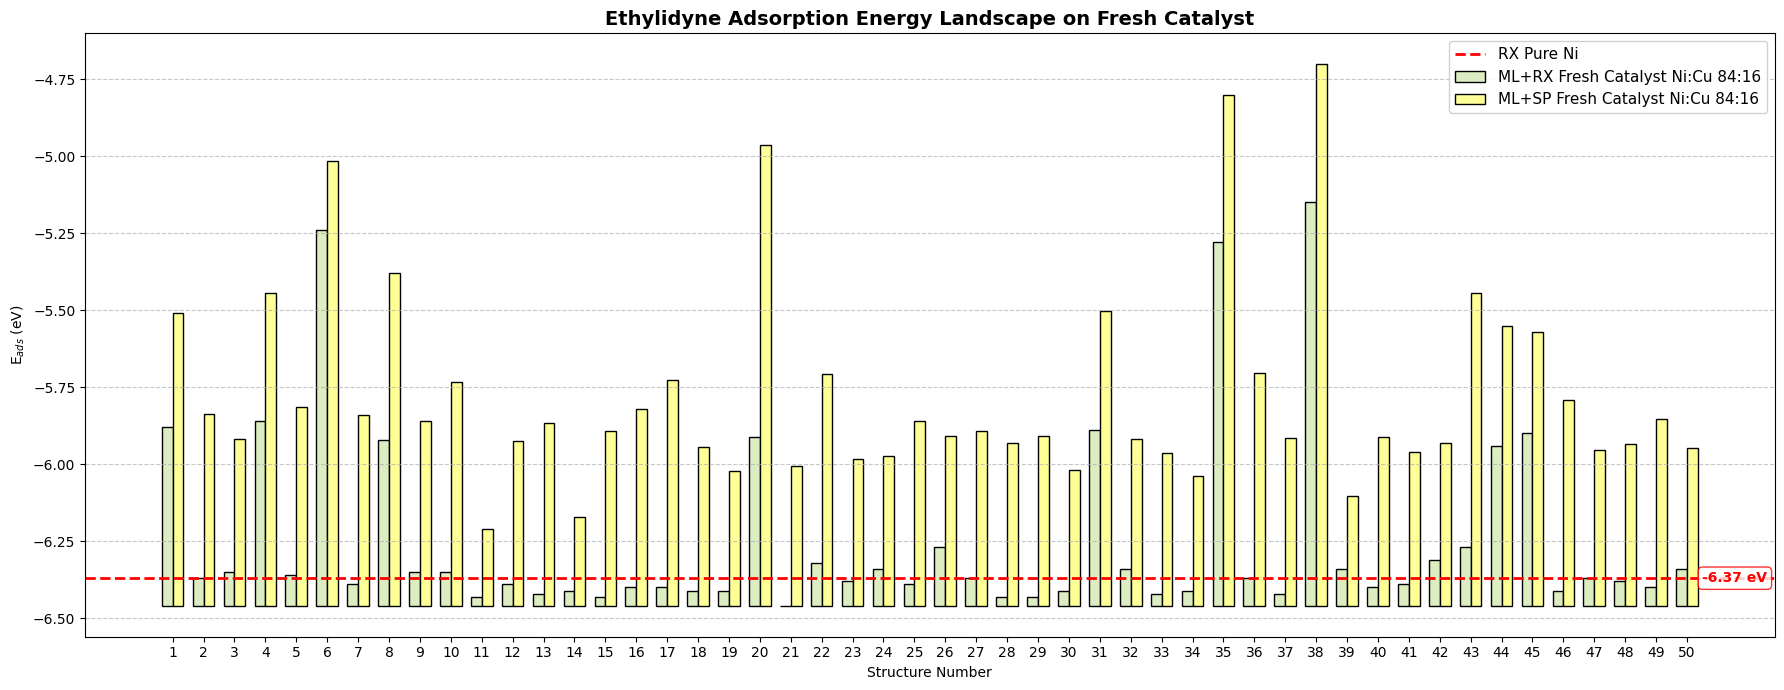

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load both datasets
data1 = np.loadtxt('/content/Eads_fresh.txt')
structure_numbers1 = data1[:, 0]
adsorption_energies1 = data1[:, 1]

data2 = np.loadtxt('/content/Eads_fresh_SP.txt')
structure_numbers2 = data2[:, 0]
adsorption_energies2 = data2[:, 1]

# Set reference energy
reference_energy = -6.37

# Find minimum energy for proper bar baseline (considering both datasets)
min_energy = min(adsorption_energies1.min(), adsorption_energies2.min(), reference_energy)

# Create bar chart with both datasets
plt.figure(figsize=(18, 7))

# Set bar width and positions for side-by-side bars
bar_width = 0.35
x1 = structure_numbers1 - bar_width/2
x2 = structure_numbers2 + bar_width/2

# Plot first dataset
bars1 = plt.bar(x1, adsorption_energies1 - min_energy, bottom=min_energy,
                width=bar_width, color='#dcedc1', edgecolor='black',
                label='ML+RX Fresh Catalyst Ni:Cu 84:16')

# Plot second dataset
bars2 = plt.bar(x2, adsorption_energies2 - min_energy, bottom=min_energy,
                width=bar_width, color='#FFFF98', edgecolor='black',
                label='ML+SP Fresh Catalyst Ni:Cu 84:16')

# Add dashed reference line
ref_line = plt.axhline(y=reference_energy, color='red', linestyle='--', linewidth=2,
                       label='RX Pure Ni')

# Add annotation for reference line
max_structure = max(structure_numbers1.max(), structure_numbers2.max())
plt.text(max_structure + 0.5, reference_energy, f'{reference_energy} eV',
         va='center', ha='left', fontsize=10, color='red', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

# Labels and title
plt.xlabel('Structure Number')
plt.ylabel('E$_{ads}$ (eV)')
plt.title('Ethylidyne Adsorption Energy Landscape on Fresh Catalyst', fontsize=14, fontweight='bold')
plt.xticks(structure_numbers1)  # Assuming same structure numbers
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
plt.legend(loc='best', framealpha=0.9, fontsize=11)

# Adjust y-axis to include all bars and reference line
max_energy = max(adsorption_energies1.max(), adsorption_energies2.max())
plt.ylim(min_energy - 0.1, max_energy + 0.1)

plt.tight_layout()
plt.savefig("fresh_comparison.png", bbox_inches='tight', dpi=300)
plt.show()

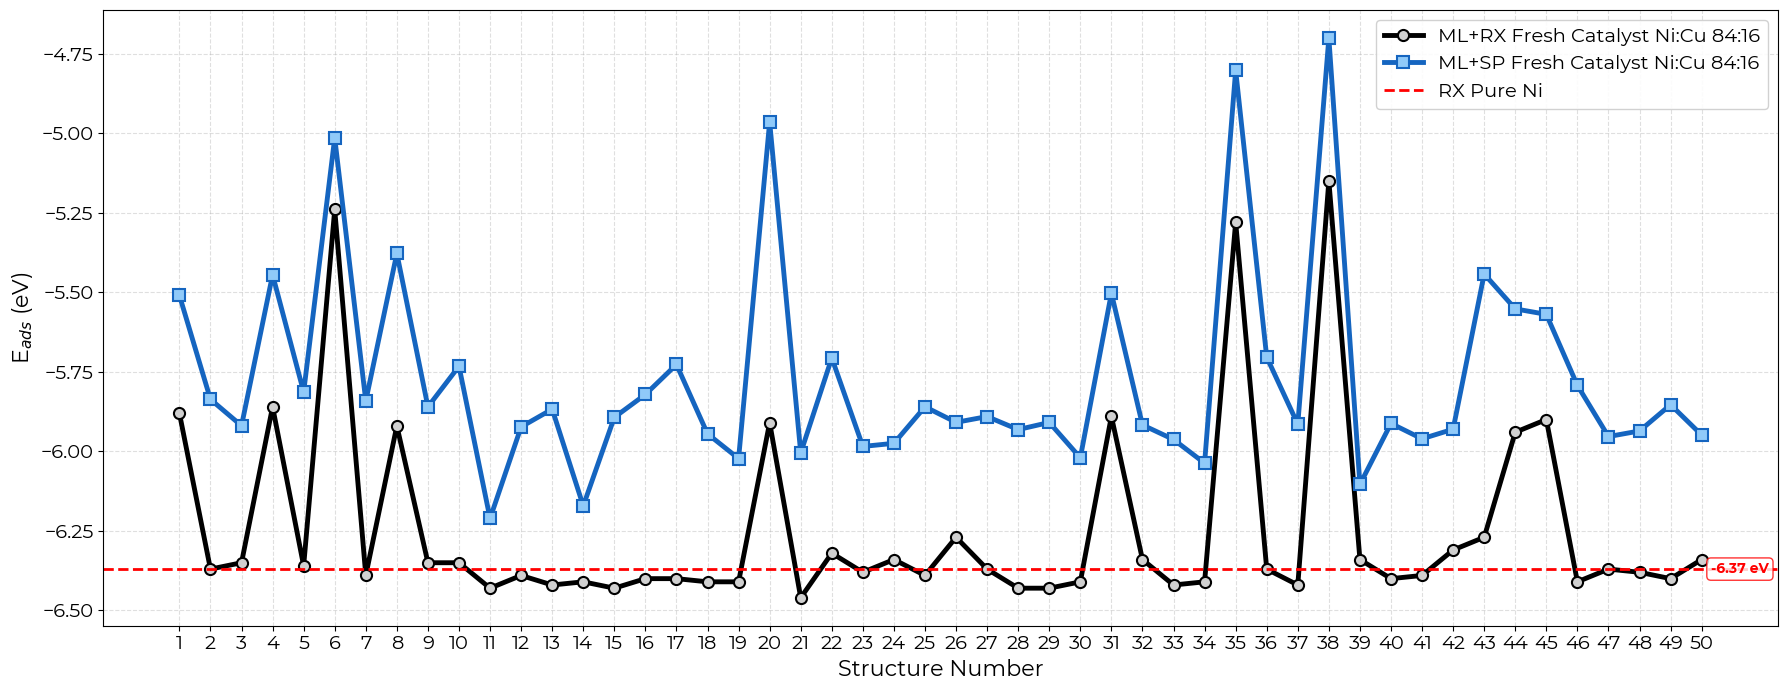

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load both datasets
data1 = np.loadtxt('/content/Eads_fresh_RX.txt')
structure_numbers1 = data1[:, 0]
adsorption_energies1 = data1[:, 1]

data2 = np.loadtxt('/content/Eads_fresh_SP.txt')
structure_numbers2 = data2[:, 0]
adsorption_energies2 = data2[:, 1]

# Set Montserrat as global font
plt.rcParams['font.family'] = 'Montserrat'

# Set reference energy
reference_energy = -6.37

# Create line plot for trend comparison
plt.figure(figsize=(18, 7))

# Plot both datasets as lines with markers
plt.plot(structure_numbers1, adsorption_energies1,
         marker='o', markersize=8, linewidth=3.5, color='black',
         markerfacecolor='#d0d0d0', markeredgecolor='black', markeredgewidth=1.5,
         label='ML+RX Regenerated Catalyst Ni:Cu 84:16')

plt.plot(structure_numbers2, adsorption_energies2,
         marker='s', markersize=8, linewidth=3.5, color='#1565C0',
         markerfacecolor='#90CAF9', markeredgecolor='#1565C0', markeredgewidth=1.5,
         label='ML+SP Fresh Catalyst Ni:Cu 84:16')

# Add dashed reference line
plt.axhline(y=reference_energy, color='red', linestyle='--', linewidth=2,
            label='RX Pure Ni')

# Add annotation for reference line
plt.text(structure_numbers1[-1] + 0.3, reference_energy, f'{reference_energy} eV',
         va='center', ha='left', fontsize=10, color='red', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

# Labels and title
plt.xlabel('Structure Number', fontsize=16)
plt.ylabel('E$_{ads}$ (eV)', fontsize=16)

plt.xticks(structure_numbers1)
plt.grid(axis='both', linestyle='--', alpha=0.4)

plt.tick_params(axis='both', labelsize=14)

# Add legend
plt.legend(loc='best', framealpha=0.9, fontsize=14,
           prop={'family': 'Montserrat', 'size': 14})

plt.tight_layout()
plt.savefig("fresh_trend_comparison.png", bbox_inches='tight', dpi=300)
plt.show()

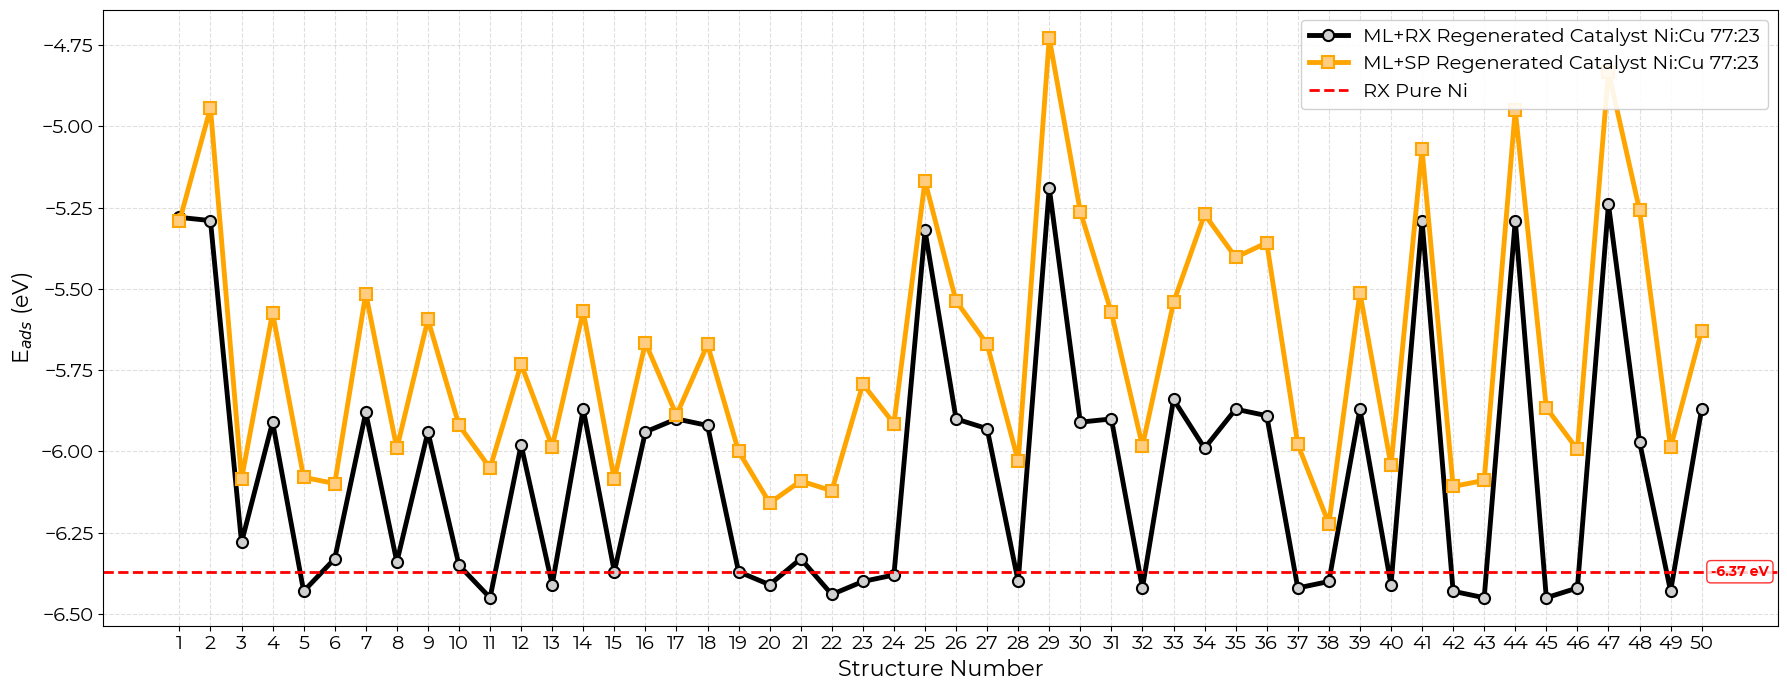

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load both datasets
data1 = np.loadtxt('/content/Eads_regenerated_RX.txt')
structure_numbers1 = data1[:, 0]
adsorption_energies1 = data1[:, 1]

data2 = np.loadtxt('/content/Eads_regenerated_SP.txt')
structure_numbers2 = data2[:, 0]
adsorption_energies2 = data2[:, 1]

# Set Montserrat as global font
plt.rcParams['font.family'] = 'Montserrat'

# Set reference energy
reference_energy = -6.37

# Create line plot for trend comparison
plt.figure(figsize=(18, 7))

# Plot both datasets as lines with markers
plt.plot(structure_numbers1, adsorption_energies1,
         marker='o', markersize=8, linewidth=3.5, color='black',
         markerfacecolor='#d0d0d0', markeredgecolor='black', markeredgewidth=1.5,
         label='ML+RX Regenerated Catalyst Ni:Cu 77:23')

plt.plot(structure_numbers2, adsorption_energies2,
         marker='s', markersize=8, linewidth=3.5, color='orange',
         markerfacecolor='#FFCC80', markeredgecolor='orange', markeredgewidth=1.5,
         label='ML+SP Regenerated Catalyst Ni:Cu 77:23')

# Add dashed reference line
plt.axhline(y=reference_energy, color='red', linestyle='--', linewidth=2,
            label='RX Pure Ni')

# Add annotation for reference line
plt.text(structure_numbers1[-1] + 0.3, reference_energy, f'{reference_energy} eV',
         va='center', ha='left', fontsize=10, color='red', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

# Labels and title
plt.xlabel('Structure Number', fontsize=16)
plt.ylabel('E$_{ads}$ (eV)', fontsize=16)

plt.xticks(structure_numbers1)
plt.grid(axis='both', linestyle='--', alpha=0.4)

plt.tick_params(axis='both', labelsize=14)

# Add legend
plt.legend(loc='best', framealpha=0.9, fontsize=14,
           prop={'family': 'Montserrat', 'size': 14})

plt.tight_layout()
plt.savefig("fresh_trend_comparison.png", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
!pip install matplotlib
!apt-get install -y fonts-urw-base35
!wget https://github.com/JulietaUla/Montserrat/raw/master/fonts/ttf/Montserrat-Regular.ttf -O /usr/share/fonts/Montserrat-Regular.ttf
!wget https://github.com/JulietaUla/Montserrat/raw/master/fonts/ttf/Montserrat-Bold.ttf -O /usr/share/fonts/Montserrat-Bold.ttf

# Clear matplotlib font cache so it picks up the new font
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

import matplotlib
matplotlib.font_manager.fontManager.addfont('/usr/share/fonts/Montserrat-Regular.ttf')
matplotlib.font_manager.fontManager.addfont('/usr/share/fonts/Montserrat-Bold.ttf')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
The following NEW packages will be installed:
  fonts-urw-base35
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 6,367 kB of archives.
After this operation, 11.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-urw-base35 all 20200910-1 [6,367 kB]
Fetched 6,367 kB in 1s (6,613 kB/s)
Selecting previously unselected package fonts-urw-base35.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-urw-base35_20200910-1_all.deb ...
Unpacking fonts-urw-base35 (20200910-1) ...
Setting up fonts-urw-base35 (20200910-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
--2026-03-09 18:26:10--  https://github.com/JulietaUla/Montserrat/raw/master/fonts/ttf/Montserrat-Regular.ttf
Resolvin

**Single plots**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = np.loadtxt('/content/Eads_regenerated.txt')
structure_numbers = data[:, 0]
adsorption_energies = data[:, 1]

# Set reference energy
reference_energy = -6.37

# Find minimum energy for proper bar baseline
min_energy = min(adsorption_energies.min(), reference_energy)  # Ensure reference is included

# Create bar chart with bars starting from minimum energy
plt.figure(figsize=(18, 7))
bars = plt.bar(structure_numbers, adsorption_energies - min_energy, bottom=min_energy,
        color='#a8e6cf', edgecolor='black', label='ML+RX Regenerated Catalyst Ni:Cu 77:23')

# Add dashed reference line
ref_line = plt.axhline(y=reference_energy, color='red', linestyle='--', linewidth=2,
                       label='RX Pure Ni')

# Add annotation for reference line
plt.text(structure_numbers[-1] + 0.5, reference_energy, f'{reference_energy} eV',
         va='center', ha='left', fontsize=10, color='red', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

# Labels and title
plt.xlabel('Structure Number')
plt.ylabel('E$_{ads}$ (eV)')
plt.title('Ethylidyne Adsorption Energy Landscape on Regenerated Catalyst', fontsize=14, fontweight='bold')
plt.xticks(structure_numbers)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
plt.legend(loc='best', framealpha=0.9, fontsize=11)

# Adjust y-axis to include all bars and reference line
plt.ylim(min_energy - 0.1, adsorption_energies.max() + 0.1)

plt.tight_layout()
plt.savefig("reg.png", bbox_inches='tight', dpi=300)
plt.show()

**Compared RX vs SP**

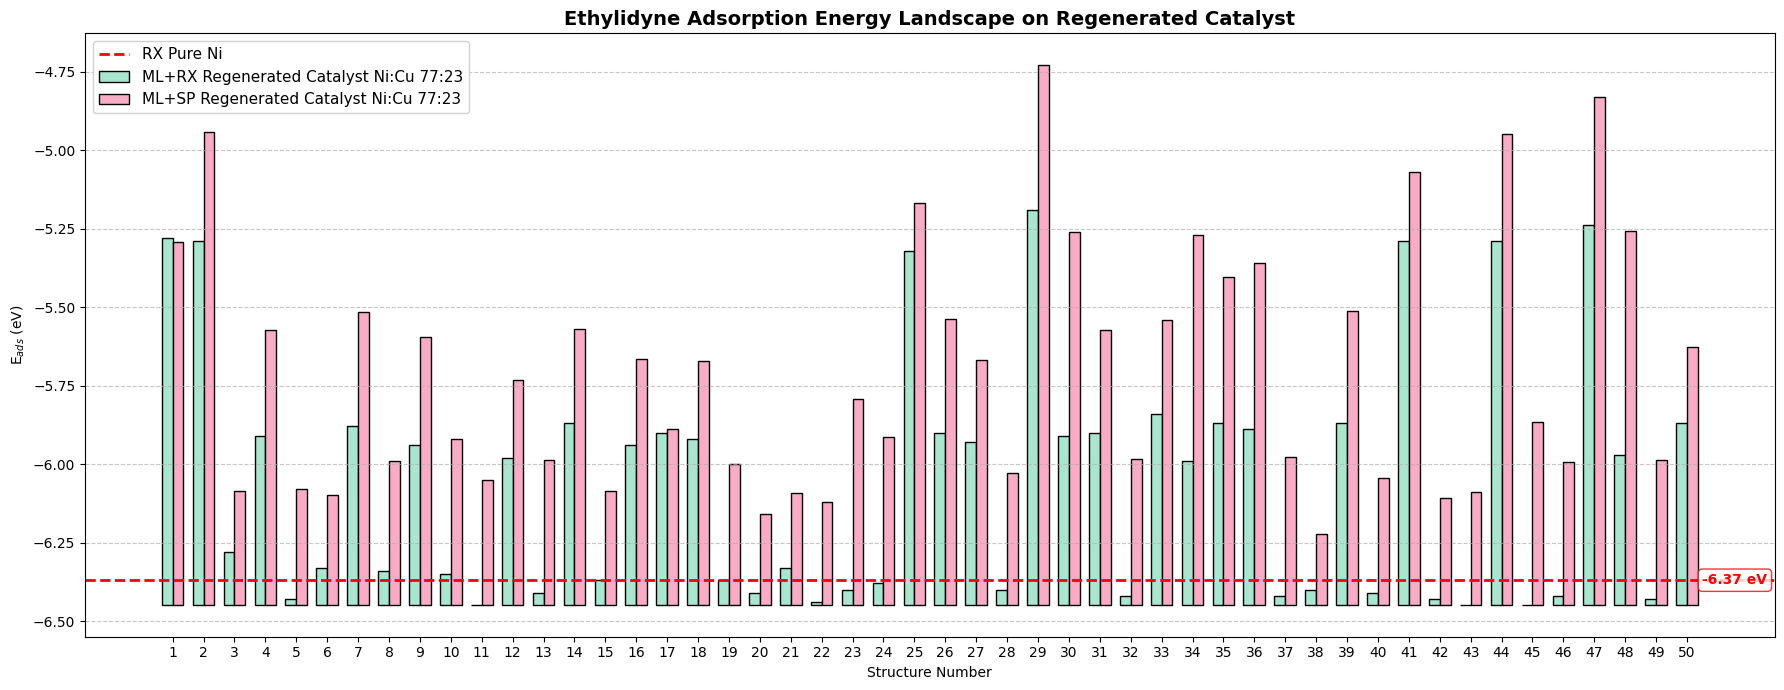

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load both datasets
data1 = np.loadtxt('/content/Eads_regenerated.txt')
structure_numbers1 = data1[:, 0]
adsorption_energies1 = data1[:, 1]

data2 = np.loadtxt('/content/Eads_regenerated_SP.txt')
structure_numbers2 = data2[:, 0]
adsorption_energies2 = data2[:, 1]

# Set reference energy
reference_energy = -6.37

# Find minimum energy for proper bar baseline (considering both datasets)
min_energy = min(adsorption_energies1.min(), adsorption_energies2.min(), reference_energy)

# Create bar chart with both datasets
plt.figure(figsize=(18, 7))

# Set bar width and positions for side-by-side bars
bar_width = 0.35
x1 = structure_numbers1 - bar_width/2
x2 = structure_numbers2 + bar_width/2

# Plot first dataset
bars1 = plt.bar(x1, adsorption_energies1 - min_energy, bottom=min_energy,
                width=bar_width, color='#a8e6cf', edgecolor='black',
                label='ML+RX Regenerated Catalyst Ni:Cu 77:23')

# Plot second dataset
bars2 = plt.bar(x2, adsorption_energies2 - min_energy, bottom=min_energy,
                width=bar_width, color='#FAABC6', edgecolor='black',
                label='ML+SP Regenerated Catalyst Ni:Cu 77:23')

# Add dashed reference line
ref_line = plt.axhline(y=reference_energy, color='red', linestyle='--', linewidth=2,
                       label='RX Pure Ni')

# Add annotation for reference line
max_structure = max(structure_numbers1.max(), structure_numbers2.max())
plt.text(max_structure + 0.5, reference_energy, f'{reference_energy} eV',
         va='center', ha='left', fontsize=10, color='red', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

# Labels and title
plt.xlabel('Structure Number')
plt.ylabel('E$_{ads}$ (eV)')
plt.title('Ethylidyne Adsorption Energy Landscape on Regenerated Catalyst', fontsize=14, fontweight='bold')
plt.xticks(structure_numbers1)  # Assuming same structure numbers
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
plt.legend(loc='best', framealpha=0.9, fontsize=11)

# Adjust y-axis to include all bars and reference line
max_energy = max(adsorption_energies1.max(), adsorption_energies2.max())
plt.ylim(min_energy - 0.1, max_energy + 0.1)

plt.tight_layout()
plt.savefig("reg_comparison.png", bbox_inches='tight', dpi=300)
plt.show()

# ML+SP 10,000 structure distribution plots

Data shape: (9986, 2)
AXIS RANGES
Configuration range: 1 to 10000
Adsorption Energy range: -11.7825 to -3.2933 eV
BASIC STATISTICS
Total configurations: 9986

Adsorption Energy Statistics:
Mean Energy: -5.71 eV
Std Dev:     0.60 eV

Plot saved as 'adsorption_energy_analysis.png'


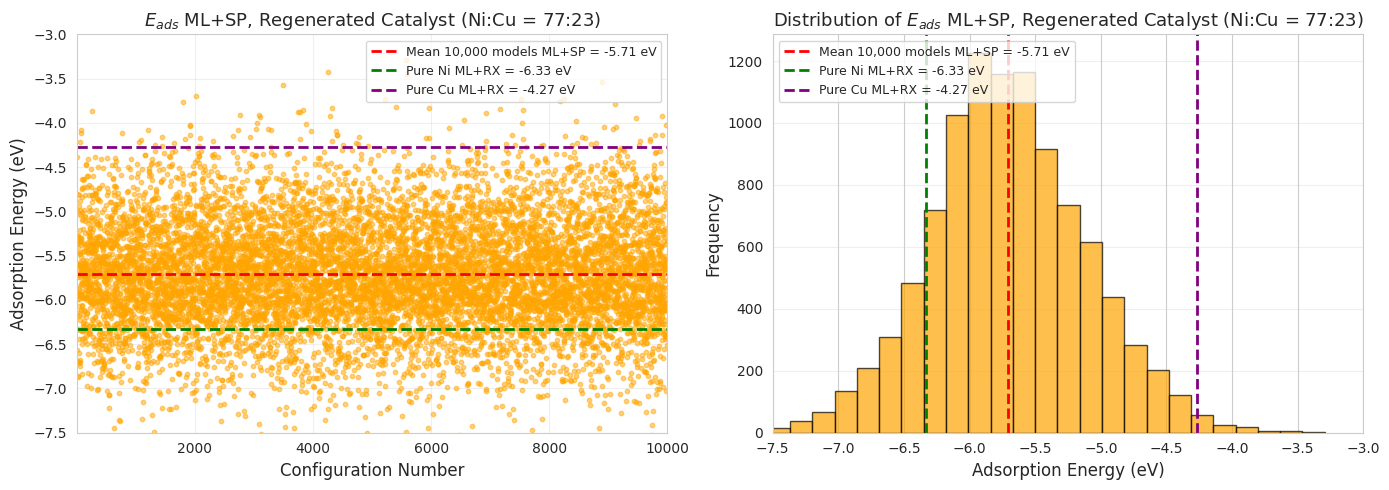

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Load the data
data = np.loadtxt('/content/0-10000_Eads_ML+SP_regenerated.txt')
print(f"Data shape: {data.shape}")

# Create DataFrame
df = pd.DataFrame(data, columns=['Configuration', 'Adsorption_Energy'])

# Shuffle for plotting (breaks job-array banding)
df_plot = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_plot['Plot_Index'] = df_plot.index + 1  # 1–10000 in random order

# Calculate mean energy (from original df)
mean_energy = df['Adsorption_Energy'].mean()

# Reference energies
eads_ni = -6.33  # Pure Ni ML+RX
eads_cu = -4.27  # Pure Cu ML+RX

# Print stats
print("=" * 50)
print("AXIS RANGES")
print("=" * 50)
print(f"Configuration range: {df['Configuration'].min():.0f} to {df['Configuration'].max():.0f}")
print(f"Adsorption Energy range: {df['Adsorption_Energy'].min():.4f} to {df['Adsorption_Energy'].max():.4f} eV")

print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
print(f"Total configurations: {len(df)}")
print(f"\nAdsorption Energy Statistics:")
print(f"Mean Energy: {mean_energy:.2f} eV")
print(f"Std Dev:     {df['Adsorption_Energy'].std():.2f} eV")

# Shared reference line definitions
ref_lines = [
    {'val': mean_energy, 'color': 'red',    'label': f'Mean 10,000 models ML+SP = {mean_energy:.2f} eV'},
    {'val': eads_ni,     'color': 'green',  'label': f'Pure Ni ML+RX = {eads_ni:.2f} eV'},
    {'val': eads_cu,     'color': 'purple', 'label': f'Pure Cu ML+RX = {eads_cu:.2f} eV'},
]

y_min, y_max = -7.5, -3.0

plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1. Scatter plot (shuffled) ───────────────────────────────────────────────
ax1 = axes[0]
ax1.scatter(df_plot['Plot_Index'], df_plot['Adsorption_Energy'],
            alpha=0.5, s=10, color='orange', rasterized=True)

for rl in ref_lines:
    ax1.axhline(y=rl['val'], color=rl['color'], linestyle='--',
                linewidth=2, label=rl['label'])

ax1.set_xlabel('Configuration Number', fontsize=12)
ax1.set_ylabel('Adsorption Energy (eV)', fontsize=12)
ax1.set_title(r'$E_{ads}$ ML+SP, Regenerated Catalyst (Ni:Cu = 77:23)',
              fontsize=13, fontweight='normal')
ax1.set_xlim(1, 10000)
ax1.set_ylim(y_min, y_max)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.8)

# ── 2. Histogram ─────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(df['Adsorption_Energy'], bins=50, color='orange',
         edgecolor='black', alpha=0.7)

for rl in ref_lines:
    ax2.axvline(x=rl['val'], color=rl['color'], linestyle='--',
                linewidth=2, label=rl['label'])

ax2.set_xlabel('Adsorption Energy (eV)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title(r'Distribution of $E_{ads}$ ML+SP, Regenerated Catalyst (Ni:Cu = 77:23)',
              fontsize=13, fontweight='normal')
ax2.set_xlim(y_min, y_max)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(loc='upper left', fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig('adsorption_energy_analysis.png', dpi=300, bbox_inches='tight')

print("\n" + "=" * 50)
print("Plot saved as 'adsorption_energy_analysis.png'")
print("=" * 50)

plt.show()

# Histogram plots for 10,000

Data shape: (9986, 2)

     N      Mean      Std    Median     Skew     Kurt
  1000   -5.6875   0.4312   -5.7632   0.6490   1.4020
  2000   -5.7012   0.5422   -5.7568   0.1992   0.6136
  3000   -5.6979   0.5726   -5.7322   0.1332   0.3961
  4000   -5.7038   0.5834   -5.7308   0.1198   0.2950
  5000   -5.7017   0.5936   -5.7274   0.1120   0.1855
  6000   -5.7029   0.5988   -5.7252   0.1154   0.1911
  7000   -5.7052   0.6008   -5.7250   0.0951   0.1915
  8000   -5.7065   0.6054   -5.7240  -0.0357   1.3509
  9000   -5.7081   0.5931   -5.7287  -0.0105   1.4054
 10000   -5.7075   0.5960   -5.7278   0.0042   1.2742

Plot saved as 'adsorption_energy_convergence.png'


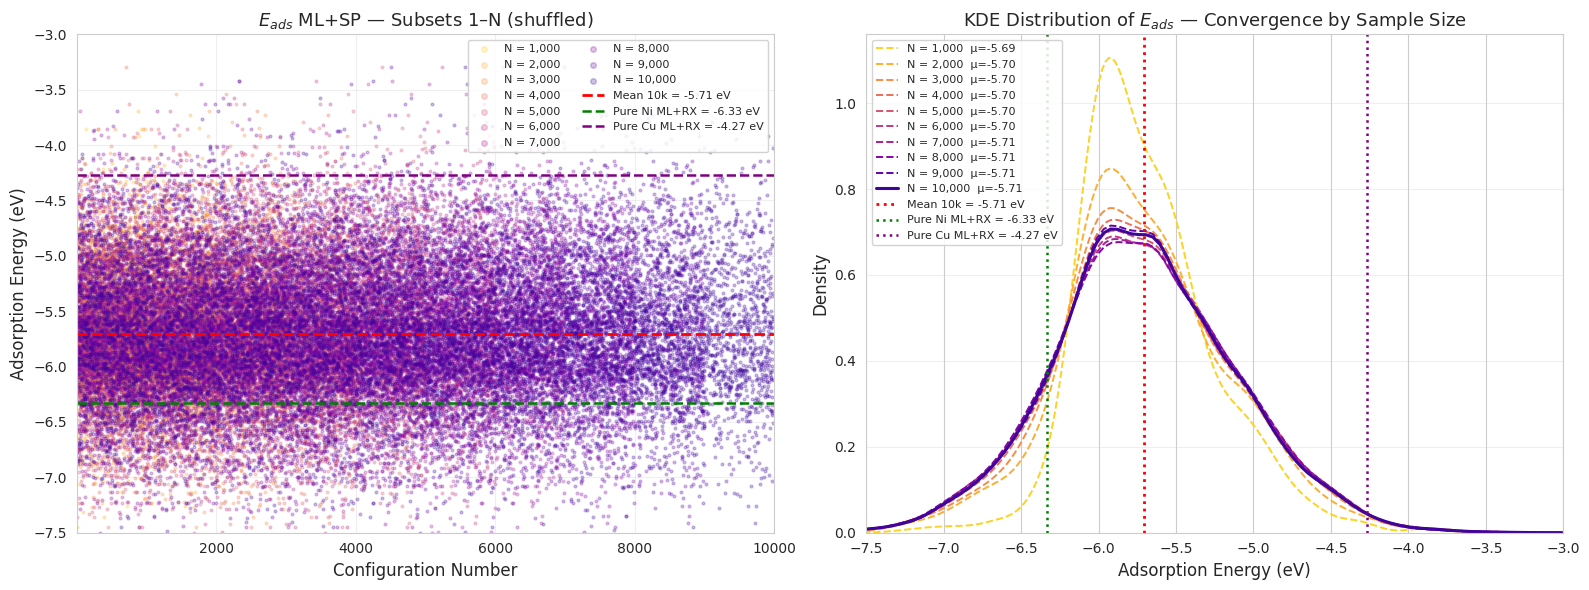

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

# ── Load data ────────────────────────────────────────────────────────────────
data = np.loadtxt('/content/0-10000_Eads_ML+SP_regenerated.txt')
print(f"Data shape: {data.shape}")

df = pd.DataFrame(data, columns=['Configuration', 'Adsorption_Energy'])

# ── Subset definitions ───────────────────────────────────────────────────────
subset_sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
palette      = sns.color_palette("plasma_r", n_colors=len(subset_sizes))

# ── Reference lines ──────────────────────────────────────────────────────────
mean_10k  = df['Adsorption_Energy'].mean()
eads_ni   = -6.33
eads_cu   = -4.27
y_min, y_max = -7.5, -3.0

ref_lines = [
    {'val': mean_10k, 'color': 'red',    'lw': 2.0,
     'label': f'Mean 10k = {mean_10k:.2f} eV'},
    {'val': eads_ni,  'color': 'green',  'lw': 1.8,
     'label': f'Pure Ni ML+RX = {eads_ni:.2f} eV'},
    {'val': eads_cu,  'color': 'purple', 'lw': 1.8,
     'label': f'Pure Cu ML+RX = {eads_cu:.2f} eV'},
]

# ── Print convergence statistics ─────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"{'N':>6}  {'Mean':>8}  {'Std':>7}  {'Median':>8}  {'Skew':>7}  {'Kurt':>7}")
print("=" * 65)
for n in subset_sizes:
    sub = df['Adsorption_Energy'].iloc[:n]
    print(f"{n:>6}  {sub.mean():>8.4f}  {sub.std():>7.4f}  "
          f"{sub.median():>8.4f}  {stats.skew(sub):>7.4f}  "
          f"{stats.kurtosis(sub):>7.4f}")
print("=" * 65)

# ── Figure ───────────────────────────────────────────────────────────────────
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── LEFT: Scatter – one trace per subset, each shuffled ─────────────────────
ax1 = axes[0]
for idx, n in enumerate(subset_sizes):
    sub = df['Adsorption_Energy'].iloc[:n].sample(frac=1, random_state=42).values
    x   = np.arange(1, len(sub) + 1)
    ax1.scatter(x, sub,
                alpha=0.25, s=4,
                color=palette[idx],
                rasterized=True,
                label=f'N = {n:,}')

for rl in ref_lines:
    ax1.axhline(y=rl['val'], color=rl['color'], linestyle='--',
                linewidth=rl['lw'], label=rl['label'])

ax1.set_xlabel('Configuration Number', fontsize=12)
ax1.set_ylabel('Adsorption Energy (eV)', fontsize=12)
ax1.set_title(r'$E_{ads}$ ML+SP — Subsets 1–N (shuffled)',
              fontsize=13)
ax1.set_xlim(1, 10000)
ax1.set_ylim(y_min, y_max)
ax1.legend(loc='upper right', fontsize=8, framealpha=0.85,
           ncol=2, markerscale=2)
ax1.grid(True, alpha=0.3)

# ── RIGHT: KDE distribution – all subsets overlaid ───────────────────────────
ax2 = axes[1]
for idx, n in enumerate(subset_sizes):
    sub = df['Adsorption_Energy'].iloc[:n]
    sns.kdeplot(sub, ax=ax2,
                color=palette[idx],
                linewidth=2.2 if n == 10000 else 1.4,
                linestyle='-' if n == 10000 else '--',
                label=f'N = {n:,}  μ={sub.mean():.2f}')

for rl in ref_lines:
    ax2.axvline(x=rl['val'], color=rl['color'], linestyle=':',
                linewidth=rl['lw'], label=rl['label'])

ax2.set_xlabel('Adsorption Energy (eV)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title(r'KDE Distribution of $E_{ads}$ — Convergence by Sample Size',
              fontsize=13)
ax2.set_xlim(y_min, y_max)
ax2.legend(loc='upper left', fontsize=8, framealpha=0.85, ncol=1)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('adsorption_energy_convergence.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as 'adsorption_energy_convergence.png'")
plt.show()

Data shape: (10000, 2)

     N      Mean      Std    Median     Skew     Kurt
  1000   -5.6788   0.3193   -5.7900   2.2437   9.9092
  2000   -5.6798   0.3094   -5.7900   1.8136   6.3683
  3000   -5.6760   0.3231   -5.7900   2.8152  25.5163
  4000   -5.6781   0.3149   -5.7800   2.5303  21.5645
  5000   -5.6793   0.3131   -5.7800   2.3680  18.3915
  6000   -5.6790   0.3362   -5.7800   1.7476  12.3311
  7000   -5.6783   0.3721   -5.7700   1.0758   7.6573
  8000   -5.6788   0.4001   -5.7600   0.7967   5.6065
  9000   -5.6820   0.4197   -5.7600   0.5902   4.4173
 10000   -5.6812   0.4337   -5.7600   0.4976   3.5652

Plot saved as 'adsorption_energy_convergence_fresh.png'


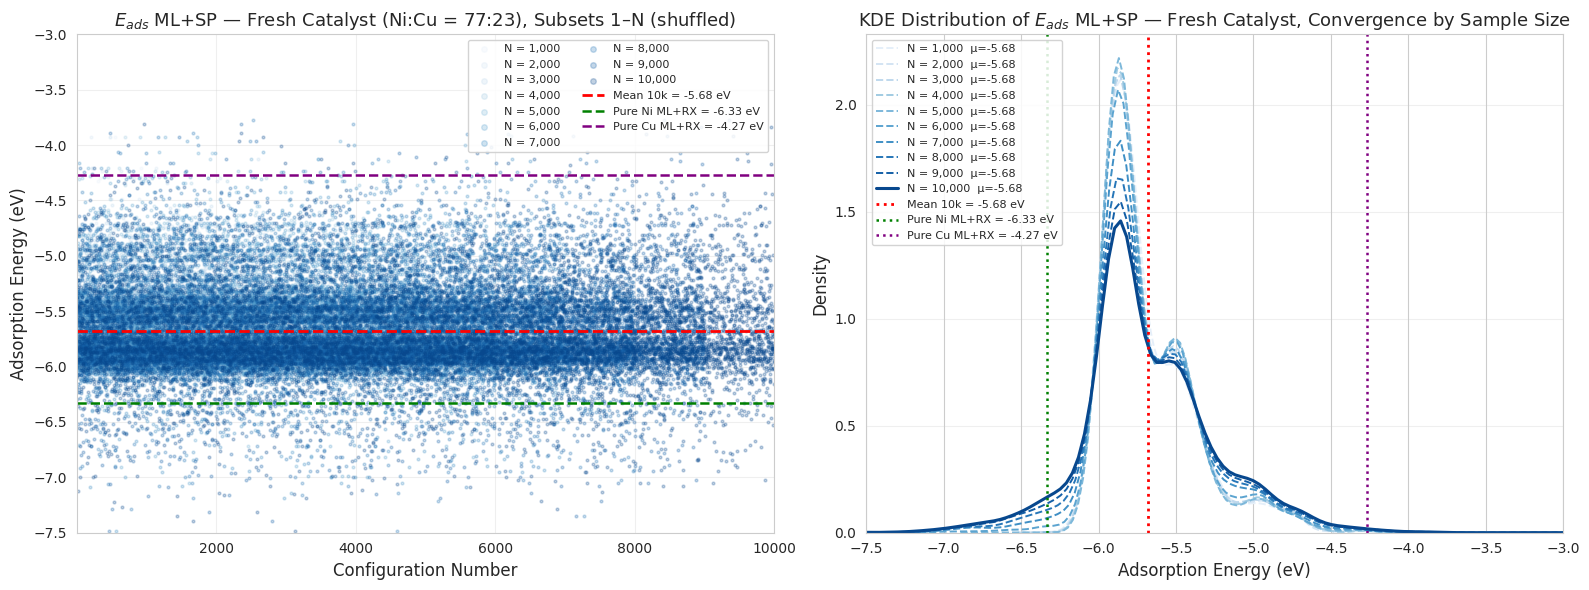

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

# ── Load data ────────────────────────────────────────────────────────────────
data = np.loadtxt('/content/0-10000_Eads_ML+SP_fresh.txt')
print(f"Data shape: {data.shape}")

df = pd.DataFrame(data, columns=['Configuration', 'Adsorption_Energy'])

# ── Subset definitions ───────────────────────────────────────────────────────
subset_sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
palette      = sns.color_palette("Blues", n_colors=len(subset_sizes))

# ── Reference lines ──────────────────────────────────────────────────────────
mean_10k  = df['Adsorption_Energy'].mean()
eads_ni   = -6.33
eads_cu   = -4.27
y_min, y_max = -7.5, -3.0

ref_lines = [
    {'val': mean_10k, 'color': 'red',    'lw': 2.0,
     'label': f'Mean 10k = {mean_10k:.2f} eV'},
    {'val': eads_ni,  'color': 'green',  'lw': 1.8,
     'label': f'Pure Ni ML+RX = {eads_ni:.2f} eV'},
    {'val': eads_cu,  'color': 'purple', 'lw': 1.8,
     'label': f'Pure Cu ML+RX = {eads_cu:.2f} eV'},
]

# ── Print convergence statistics ─────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"{'N':>6}  {'Mean':>8}  {'Std':>7}  {'Median':>8}  {'Skew':>7}  {'Kurt':>7}")
print("=" * 65)
for n in subset_sizes:
    sub = df['Adsorption_Energy'].iloc[:n]
    print(f"{n:>6}  {sub.mean():>8.4f}  {sub.std():>7.4f}  "
          f"{sub.median():>8.4f}  {stats.skew(sub):>7.4f}  "
          f"{stats.kurtosis(sub):>7.4f}")
print("=" * 65)

# ── Figure ───────────────────────────────────────────────────────────────────
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── LEFT: Scatter – one trace per subset, each shuffled ─────────────────────
ax1 = axes[0]
for idx, n in enumerate(subset_sizes):
    sub = df['Adsorption_Energy'].iloc[:n].sample(frac=1, random_state=42).values
    x   = np.arange(1, len(sub) + 1)
    ax1.scatter(x, sub,
                alpha=0.25, s=4,
                color=palette[idx],
                rasterized=True,
                label=f'N = {n:,}')

for rl in ref_lines:
    ax1.axhline(y=rl['val'], color=rl['color'], linestyle='--',
                linewidth=rl['lw'], label=rl['label'])

ax1.set_xlabel('Configuration Number', fontsize=12)
ax1.set_ylabel('Adsorption Energy (eV)', fontsize=12)
ax1.set_title(r'$E_{ads}$ ML+SP — Fresh Catalyst (Ni:Cu = 77:23), Subsets 1–N (shuffled)',
              fontsize=13)
ax1.set_xlim(1, 10000)
ax1.set_ylim(y_min, y_max)
ax1.legend(loc='upper right', fontsize=8, framealpha=0.85,
           ncol=2, markerscale=2)
ax1.grid(True, alpha=0.3)

# ── RIGHT: KDE distribution – all subsets overlaid ───────────────────────────
ax2 = axes[1]
for idx, n in enumerate(subset_sizes):
    sub = df['Adsorption_Energy'].iloc[:n]
    sns.kdeplot(sub, ax=ax2,
                color=palette[idx],
                linewidth=2.2 if n == 10000 else 1.4,
                linestyle='-' if n == 10000 else '--',
                label=f'N = {n:,}  μ={sub.mean():.2f}')

for rl in ref_lines:
    ax2.axvline(x=rl['val'], color=rl['color'], linestyle=':',
                linewidth=rl['lw'], label=rl['label'])

ax2.set_xlabel('Adsorption Energy (eV)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title(r'KDE Distribution of $E_{ads}$ ML+SP — Fresh Catalyst, Convergence by Sample Size',
              fontsize=13)
ax2.set_xlim(y_min, y_max)
ax2.legend(loc='upper left', fontsize=8, framealpha=0.85, ncol=1)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('adsorption_energy_convergence_fresh.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as 'adsorption_energy_convergence_fresh.png'")
plt.show()